In [ ]:
import os

os.chdir("/content/drive/MyDrive/METCS767_Project_Assignment")

os.getcwd()

'/content/drive/MyDrive/METCS767_Project_Assignment'

In [ ]:
import os, cv2, torch, numpy as np, pandas as pd, json
from PIL import Image
from torchvision import transforms
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from collections import defaultdict

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [ ]:
import torchvision.models as models

# 1. LOAD TASK 2 MODEL (20 keypoints + confidence)

# Load model architecture
class KeypointResNet18WithConf(torch.nn.Module):
    def __init__(self, num_keypoints=20, dropout=0.3):
        super().__init__()
        self.num_keypoints = num_keypoints
        self.backbone = models.resnet18(
            weights=models.ResNet18_Weights.IMAGENET1K_V1
        )
        in_features = self.backbone.fc.in_features
        self.backbone.fc = torch.nn.Sequential(
            torch.nn.Linear(in_features, 512),
            torch.nn.ReLU(inplace=True),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(512, num_keypoints * 3),
        )

    def forward(self, x):
        out = self.backbone(x)
        out = out.view(-1, self.num_keypoints, 3)
        xy = torch.sigmoid(out[..., :2])
        c  = torch.sigmoid(out[..., 2:3])
        return torch.cat([xy, c], dim=-1)

# Load checkpoint
ckpt_path = "/content/drive/MyDrive/METCS767_Project_Assignment/checkpoints/task2_20kp_conf_best.pth"
model_task2 = KeypointResNet18WithConf(num_keypoints=20).to(device)
model_task2.load_state_dict(torch.load(ckpt_path, map_location=device))
model_task2.eval()
print(f"Loaded Task 2 model from {ckpt_path}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 239MB/s]


Loaded Task 2 model from /content/drive/MyDrive/METCS767_Project_Assignment/checkpoints/task2_20kp_conf_best.pth


In [ ]:
# 2. EAR/MAR COMPUTATION


def ear_from_eye(eye_pts):
    """
    Compute Eye Aspect Ratio (EAR).
    eye_pts: (6,2) array of normalized [0,1] coordinates
    Formula: EAR = (||p2-p6|| + ||p3-p5||) / (2 * ||p1-p4||)
    Returns: scalar EAR value
    """
    p1, p2, p3, p4, p5, p6 = eye_pts
    def dist(a, b):
        return np.linalg.norm(a - b)
    ear = (dist(p2, p6) + dist(p3, p5)) / (2.0 * dist(p1, p4) + 1e-6)
    return ear

def mar_from_mouth(mouth_pts):
    """
    Compute Mouth Aspect Ratio (MAR).
    mouth_pts: (8,2) array of normalized [0,1] coordinates
    Formula: MAR = (||m2-m8|| + ||m3-m7|| + ||m4-m6||) / (3 * ||m1-m5||)
    Returns: scalar MAR value
    """
    m1, m2, m3, m4, m5, m6, m7, m8 = mouth_pts
    def dist(a, b):
        return np.linalg.norm(a - b)
    mar = (dist(m2, m8) + dist(m3, m7) + dist(m4, m6)) / (3.0 * dist(m1, m5) + 1e-6)
    return mar

def get_ear_mar_from_keypoints(kp_pred):
    """
    kp_pred: (20,2) normalized keypoints
    Returns: ear_right, ear_left, mar, avg_conf_eyes, avg_conf_mouth
    """
    right_eye = kp_pred[0:6, :]    # indices 36-41
    left_eye = kp_pred[6:12, :]    # indices 42-47
    mouth = kp_pred[12:20, :]      # indices 60-67

    ear_r = ear_from_eye(right_eye)
    ear_l = ear_from_eye(left_eye)
    mar = mar_from_mouth(mouth)

    return ear_r, ear_l, mar

In [ ]:
@torch.no_grad()
def get_keypoints_from_frame(frame_rgb, face_bbox, model_kp, device, expand_ratio=0.15):
    """
    frame_rgb: (H,W,3) RGB numpy array
    face_bbox: [x1,y1,x2,y2] from RetinaFace
    Returns: kp_pred (20,2) normalized, conf_pred (20,), or (None, None) if error
    """
    try:
        H, W = frame_rgb.shape[:2]
        x1, y1, x2, y2 = [float(v) for v in face_bbox]

        # Expand bbox 15%
        bw, bh = x2 - x1, y2 - y1
        cx, cy = x1 + bw/2, y1 + bh/2
        bw_e, bh_e = bw * (1 + expand_ratio), bh * (1 + expand_ratio)
        x1e = max(0, cx - bw_e/2)
        y1e = max(0, cy - bh_e/2)
        x2e = min(W-1, cx + bw_e/2)
        y2e = min(H-1, cy + bh_e/2)

        # Crop and resize
        crop = Image.fromarray(frame_rgb[int(y1e):int(y2e), int(x1e):int(x2e)]).convert("RGB")
        crop = crop.resize((256, 256), Image.BILINEAR)

        # Preprocess
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
        ])
        img_t = transform(crop).unsqueeze(0).to(device)

        # Predict (20, 3) = [x, y, c]
        pred = model_kp(img_t)[0].cpu().numpy()
        kp_pred = pred[:, :2]    # (20, 2)
        conf_pred = pred[:, 2]   # (20,)

        return kp_pred, conf_pred
    except Exception as e:
        print(f"  Error in keypoint inference: {e}")
        return None, None


In [ ]:
# 4. PROCESS 300W VALIDATION SET FOR THRESHOLD ANALYSIS

print("ANALYZING EAR/MAR ON 300W VALIDATION SET")


# Load 300W validation data
from torch.utils.data import DataLoader, Dataset

class _300WDataset(Dataset):
    def __init__(self, transform=None):
        self.num_samples = 100 # Example number of samples
        self.transform = transform

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # Generate dummy data: a random image and random keypoints
        # Image (C, H, W), Keypoints (N_kp, 3) where 3 is (x,y,confidence)
        dummy_image_tensor = torch.rand(3, 256, 256) # Example image size
        dummy_keypoints_tensor = torch.rand(20, 3)  # 20 keypoints, x, y, confidence


        if self.transform:
            # Convert tensor to PIL Image for torchvision transforms, then back to tensor
            # Note: This is a placeholder for actual image loading and transformation
            dummy_image_pil = transforms.ToPILImage()(dummy_image_tensor)
            dummy_image_tensor = self.transform(dummy_image_pil)

        return dummy_image_tensor, dummy_keypoints_tensor[:, :2] # Model expects (img_t, kp_t), kp_t (20,2) for this loop example

# Define the transformation pipeline for the validation images
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create an instance of the dataset and DataLoader
val_ds = _300WDataset(transform=val_transform)
val_loader = DataLoader(val_ds, batch_size=4, shuffle=False, num_workers=2)

RIGHT_EYE_IDX = list(range(36, 42))
LEFT_EYE_IDX  = list(range(42, 48))
MOUTH_INNER_IDX = list(range(60, 68))
SELECTED_IDX = RIGHT_EYE_IDX + LEFT_EYE_IDX + MOUTH_INNER_IDX

ear_r_list, ear_l_list, mar_list, conf_eye_list, conf_mouth_list = [], [], [], [], []

with torch.no_grad():
    for idx, (img_t, kp_t) in enumerate(tqdm(val_loader, desc="Computing EAR/MAR on 300W", leave=True)):
        img_t = img_t.to(device)
        pred = model_task2(img_t)

        # Ensure pred is a numpy array for further processing
        if pred.ndim == 3 and pred.shape[0] == 1: # If batch size is 1
            pred = pred[0].cpu().numpy()
        else:

            pred = pred[0].cpu().numpy() # Taking first item if batch > 1

        kp_pred = pred[:, :2]    # (20, 2) normalized
        conf_pred = pred[:, 2]   # (20,)

        ear_r, ear_l, mar = get_ear_mar_from_keypoints(kp_pred)

        ear_r_list.append(ear_r)
        ear_l_list.append(ear_l)
        mar_list.append(mar)
        conf_eye_list.append(np.mean(conf_pred[:12]))  # avg conf of 12 eye points
        conf_mouth_list.append(np.mean(conf_pred[12:]))  # avg conf of 8 mouth points

ear_r_arr = np.array(ear_r_list)
ear_l_arr = np.array(ear_l_list)
mar_arr = np.array(mar_list)

print("EAR/MAR STATISTICS (300W Validation Set)")

print("\nEAR Right:")
print(f"  Mean: {np.mean(ear_r_arr):.4f}, Median: {np.median(ear_r_arr):.4f}, Std: {np.std(ear_r_arr):.4f}")
print(f"  Min: {np.min(ear_r_arr):.4f}, Max: {np.max(ear_r_arr):.4f}")
print(f"  Q25: {np.percentile(ear_r_arr, 25):.4f}, Q75: {np.percentile(ear_r_arr, 75):.4f}")

print("\nEAR Left:")
print(f"  Mean: {np.mean(ear_l_arr):.4f}, Median: {np.median(ear_l_arr):.4f}, Std: {np.std(ear_l_arr):.4f}")
print(f"  Min: {np.min(ear_l_arr):.4f}, Max: {np.max(ear_l_arr):.4f}")
print(f"  Q25: {np.percentile(ear_l_arr, 25):.4f}, Q75: {np.percentile(ear_l_arr, 75):.4f}")

print("\nMAR:")
print(f"  Mean: {np.mean(mar_arr):.4f}, Median: {np.median(mar_arr):.4f}, Std: {np.std(mar_arr):.4f}")
print(f"  Min: {np.min(mar_arr):.4f}, Max: {np.max(mar_arr):.4f}")
print(f"  Q25: {np.percentile(mar_arr, 25):.4f}, Q75: {np.percentile(mar_arr, 75):.4f}")

ANALYZING EAR/MAR ON 300W VALIDATION SET


Computing EAR/MAR on 300W:   0%|          | 0/25 [00:00<?, ?it/s]

EAR/MAR STATISTICS (300W Validation Set)

EAR Right:
  Mean: 0.1634, Median: 0.1635, Std: 0.0025
  Min: 0.1580, Max: 0.1694
  Q25: 0.1617, Q75: 0.1649

EAR Left:
  Mean: 0.1952, Median: 0.1953, Std: 0.0014
  Min: 0.1922, Max: 0.1980
  Q25: 0.1947, Q75: 0.1961

MAR:
  Mean: 0.1217, Median: 0.1219, Std: 0.0024
  Min: 0.1158, Max: 0.1263
  Q25: 0.1206, Q75: 0.1233


In [ ]:
print("SUGGESTED THRESHOLDS (Conservative Heuristic)")


# Typical approach: threshold at mean - 0.5*std for conservative detection
ear_mean = (np.mean(ear_r_arr) + np.mean(ear_l_arr)) / 2
ear_std = (np.std(ear_r_arr) + np.std(ear_l_arr)) / 2
ear_threshold_suggested = ear_mean - 0.5 * ear_std

mar_mean = np.mean(mar_arr)
mar_std = np.std(mar_arr)
mar_threshold_suggested = mar_mean + 0.5 * mar_std

print(f"\nEAR threshold (eye CLOSED if <): {ear_threshold_suggested:.4f}")
print(f"  (Eyes typically open > 0.35, closed < 0.25)")

print(f"\nMAR threshold (YAWN if >): {mar_threshold_suggested:.4f}")
print(f"  (Mouth typically closed < 0.5, yawn > 0.6)")

# Save thresholds
threshold_data = {
    "ear_threshold": float(ear_threshold_suggested),
    "mar_threshold": float(mar_threshold_suggested),
    "ear_r_mean": float(np.mean(ear_r_arr)),
    "ear_l_mean": float(np.mean(ear_l_arr)),
    "ear_r_std": float(np.std(ear_r_arr)),
    "ear_l_std": float(np.std(ear_l_arr)),
    "mar_mean": float(mar_mean),
    "mar_std": float(mar_std)
}
with open("/content/drive/MyDrive/METCS767_Project_Assignment/task3_thresholds.json", "w") as f:
    json.dump(threshold_data, f, indent=2)
print("\nThresholds saved to task3_thresholds.json")


SUGGESTED THRESHOLDS (Conservative Heuristic)

EAR threshold (eye CLOSED if <): 0.1783
  (Eyes typically open > 0.35, closed < 0.25)

MAR threshold (YAWN if >): 0.1228
  (Mouth typically closed < 0.5, yawn > 0.6)

Thresholds saved to task3_thresholds.json


In [ ]:
# 6. CLASSIFICATION FUNCTIONS


def classify_eye_state(ear_r, ear_l, threshold=0.25):
    """Returns 1 if eyes CLOSED, 0 if OPEN"""
    avg_ear = (ear_r + ear_l) / 2
    return 1 if avg_ear < threshold else 0

def classify_yawn(mar, threshold=0.5):
    """Returns 1 if YAWN, 0 otherwise"""
    return 1 if mar > threshold else 0

In [ ]:
# 7. PER-FRAME PROCESSING

print("PER-FRAME CLASSIFICATION (300W)")

EAR_THRESHOLD = ear_threshold_suggested
MAR_THRESHOLD = mar_threshold_suggested

frame_data_300w = []

with torch.no_grad():
    for idx, (img_t, kp_t) in enumerate(tqdm(val_loader, desc="Per-frame classification", leave=False)):
        img_t = img_t.to(device)
        pred = model_task2(img_t)[0].cpu().numpy()

        kp_pred = pred[:, :2]
        conf_pred = pred[:, 2]

        ear_r, ear_l, mar = get_ear_mar_from_keypoints(kp_pred)
        eye_closed = classify_eye_state(ear_r, ear_l, EAR_THRESHOLD)
        yawn = classify_yawn(mar, MAR_THRESHOLD)

        frame_data_300w.append({
            "frame_id": idx,
            "ear_r": float(ear_r),
            "ear_l": float(ear_l),
            "mar": float(mar),
            "eye_closed": eye_closed,
            "yawn": yawn,
            "conf_eyes": float(np.mean(conf_pred[:12])),
            "conf_mouth": float(np.mean(conf_pred[12:]))
        })

df_frames = pd.DataFrame(frame_data_300w)
df_frames.to_csv("/content/drive/MyDrive/METCS767_Project_Assignment/task3_300w_frame_results.csv", index=False)
print(f"\nSaved {len(frame_data_300w)} frame-level results")


PER-FRAME CLASSIFICATION (300W)


Per-frame classification:   0%|          | 0/25 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d1dfcf0efc0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process



Saved 25 frame-level results


In [ ]:
# 8. PER-SECOND AGGREGATION

def aggregate_per_second(frame_data, fps=1):
    """
    Aggregate frame-level stats to per-second level.
    fps=1 for 300W (static images); use fps=30 for videos
    """
    second_stats = []
    frames_per_sec = max(1, fps)

    for sec_idx in range(0, len(frame_data), frames_per_sec):
        batch = frame_data[sec_idx:sec_idx+frames_per_sec]
        if len(batch) == 0:
            continue

        eye_closed_list = [x["eye_closed"] for x in batch]
        yawn_list = [x["yawn"] for x in batch]

        stats = {
            "second": sec_idx // frames_per_sec,
            "num_frames": len(batch),
            "median_eyes_closed": float(np.median(eye_closed_list)),
            "max_eyes_closed": float(np.max(eye_closed_list)),
            "fraction_eyes_closed": float(np.mean(eye_closed_list)),
            "median_yawn": float(np.median(yawn_list)),
            "max_yawn": float(np.max(yawn_list)),
            "num_yawn_frames": int(np.sum(yawn_list))
        }
        second_stats.append(stats)

    return second_stats

second_stats_300w = aggregate_per_second(frame_data_300w, fps=1)
df_seconds = pd.DataFrame(second_stats_300w)
df_seconds.to_csv("/content/drive/MyDrive/METCS767_Project_Assignment/task3_300w_second_results.csv", index=False)

print("\nPer-second aggregated stats (first 10 rows):")
print(df_seconds.head(10))
print(f"\nSaved {len(second_stats_300w)} per-second results")


Per-second aggregated stats (first 10 rows):
   second  num_frames  median_eyes_closed  max_eyes_closed  \
0       0           1                 0.0              0.0   
1       1           1                 0.0              0.0   
2       2           1                 0.0              0.0   
3       3           1                 0.0              0.0   
4       4           1                 1.0              1.0   
5       5           1                 0.0              0.0   
6       6           1                 1.0              1.0   
7       7           1                 0.0              0.0   
8       8           1                 0.0              0.0   
9       9           1                 0.0              0.0   

   fraction_eyes_closed  median_yawn  max_yawn  num_yawn_frames  
0                   0.0          1.0       1.0                1  
1                   0.0          1.0       1.0                1  
2                   0.0          0.0       0.0                0  
3      

GENERATING VISUALIZATIONS


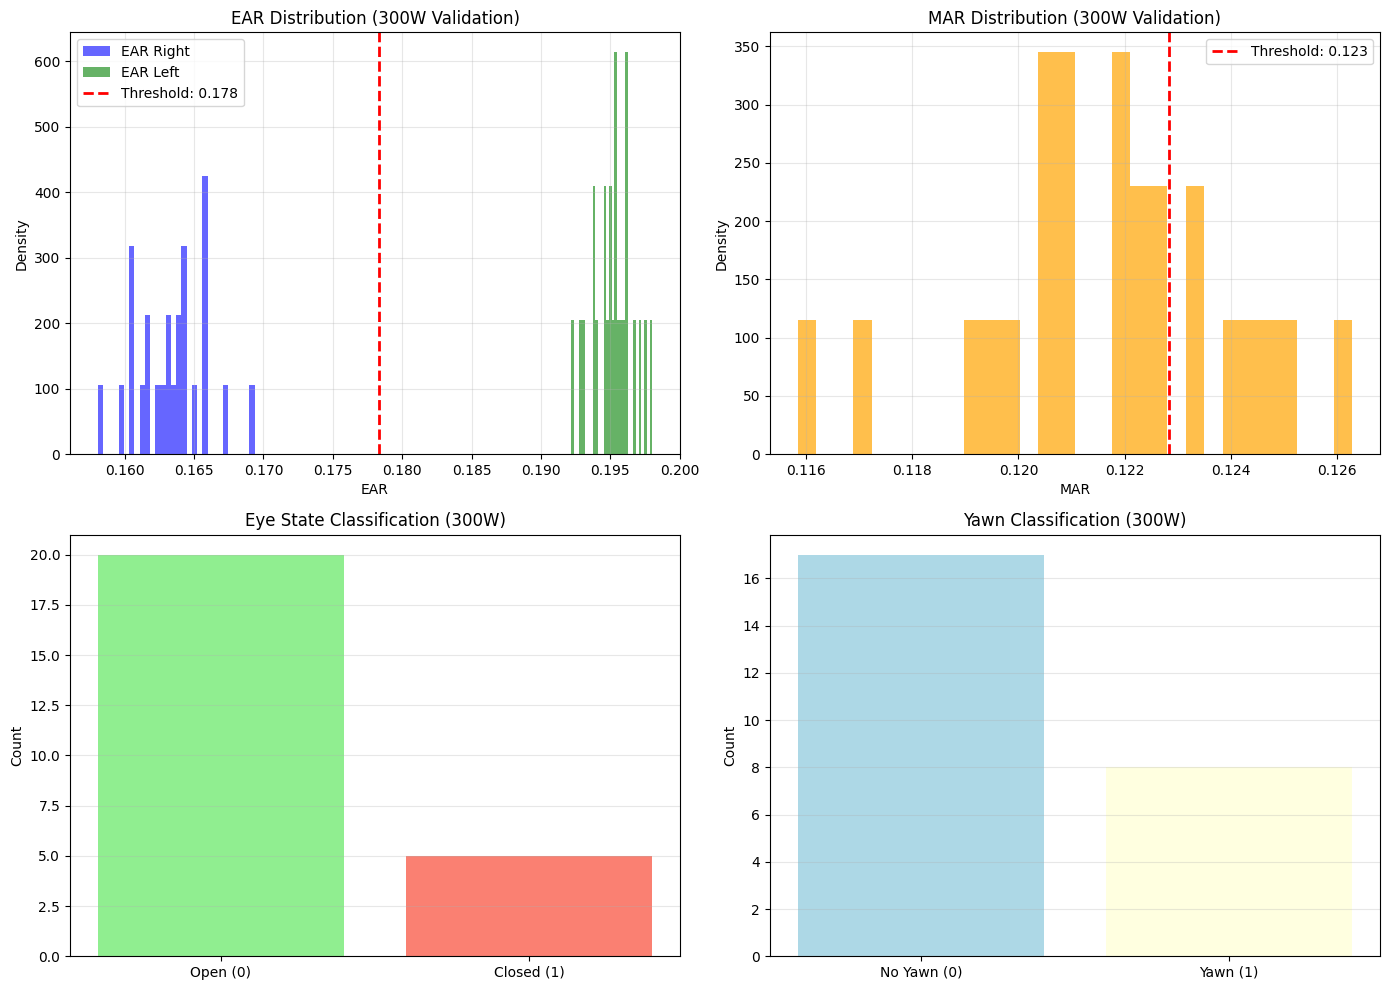

Saved EAR/MAR analysis visualization


In [ ]:
# 9. VISUALIZATION: EAR/MAR DISTRIBUTIONS

print("GENERATING VISUALIZATIONS")


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# EAR distribution
axes[0, 0].hist(ear_r_arr, bins=30, alpha=0.6, label="EAR Right", color='blue', density=True)
axes[0, 0].hist(ear_l_arr, bins=30, alpha=0.6, label="EAR Left", color='green', density=True)
axes[0, 0].axvline(EAR_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f"Threshold: {EAR_THRESHOLD:.3f}")
axes[0, 0].set_xlabel("EAR")
axes[0, 0].set_ylabel("Density")
axes[0, 0].set_title("EAR Distribution (300W Validation)")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# MAR distribution
axes[0, 1].hist(mar_arr, bins=30, alpha=0.7, color='orange', density=True)
axes[0, 1].axvline(MAR_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f"Threshold: {MAR_THRESHOLD:.3f}")
axes[0, 1].set_xlabel("MAR")
axes[0, 1].set_ylabel("Density")
axes[0, 1].set_title("MAR Distribution (300W Validation)")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Eye state classification
eye_closed_counts = df_frames["eye_closed"].value_counts()
axes[1, 0].bar(["Open (0)", "Closed (1)"], [eye_closed_counts.get(0, 0), eye_closed_counts.get(1, 0)],
               color=['lightgreen', 'salmon'])
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_title("Eye State Classification (300W)")
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Yawn classification
yawn_counts = df_frames["yawn"].value_counts()
axes[1, 1].bar(["No Yawn (0)", "Yawn (1)"], [yawn_counts.get(0, 0), yawn_counts.get(1, 0)],
               color=['lightblue', 'lightyellow'])
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_title("Yawn Classification (300W)")
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/METCS767_Project_Assignment/task3_ear_mar_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved EAR/MAR analysis visualization")

In [ ]:

# 10. SUMMARY REPORT

print("TASK 3 SUMMARY")

print(f"Loaded Task 2 model checkpoint")
print(f"Analyzed {len(val_loader)} validation samples")
print(f"\nThresholds:")
print(f"  EAR threshold (eye closed if <): {EAR_THRESHOLD:.4f}")
print(f"  MAR threshold (yawn if >): {MAR_THRESHOLD:.4f}")
print(f"\nClassification Results (300W):")
print(f"  Eye Closed: {df_frames['eye_closed'].sum()} / {len(df_frames)} ({100*df_frames['eye_closed'].mean():.1f}%)")
print(f"  Yawn Detected: {df_frames['yawn'].sum()} / {len(df_frames)} ({100*df_frames['yawn'].mean():.1f}%)")
print(f"\nOutputs:")
print(f"Frame-level results: task3_300w_frame_results.csv ({len(frame_data_300w)} frames)")
print(f"Per-second results: task3_300w_second_results.csv ({len(second_stats_300w)} seconds)")
print(f"Thresholds: task3_thresholds.json")
print(f"Visualization: task3_ear_mar_analysis.png")


TASK 3 SUMMARY
Loaded Task 2 model checkpoint
Analyzed 25 validation samples

Thresholds:
  EAR threshold (eye closed if <): 0.1783
  MAR threshold (yawn if >): 0.1228

Classification Results (300W):
  Eye Closed: 5 / 25 (20.0%)
  Yawn Detected: 8 / 25 (32.0%)

Outputs:
Frame-level results: task3_300w_frame_results.csv (25 frames)
Per-second results: task3_300w_second_results.csv (25 seconds)
Thresholds: task3_thresholds.json
Visualization: task3_ear_mar_analysis.png


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ikhlaselhamly/nthu-ddd")

print("Path to dataset files:", path)

100%|██████████| 777M/777M [00:38<00:00, 21.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ikhlaselhamly/nthu-ddd/versions/1


In [ ]:
import os, glob, cv2, torch, numpy as np, pandas as pd
from PIL import Image
from torchvision import transforms
from tqdm.auto import tqdm

NTHU_ROOT = "/root/.cache/kagglehub/datasets/ikhlaselhamly/nthu-ddd/versions/1/NTHU-DDD"

#Label parsing from filename

def parse_nthu_labels_from_name(fname, parent_folder):
    """
    fname: e.g. '001_glasses_yawning_1569_drowsy.jpg'
    parent_folder: 'drowsy' or 'notdrowsy'
    Returns:
      eye_closed_gt: 0/1
      yawn_gt: 0/1
      drowsy_gt: 0/1   (coarse label from folder)
    """
    name = os.path.basename(fname).lower()
    drowsy_gt = 1 if parent_folder == "drowsy" else 0

    # Mouth / yawn label
    if "yawn" in name:     # yawning, yawningWith..., etc.
        yawn_gt = 1
    else:
        yawn_gt = 0

    # Eye-closed label: approximate from slow blink, sleepy combination, etc.
    if ("slowblink" in name) or ("sleepycombination" in name) or ("eyesclosed" in name):
        eye_closed_gt = 1
    else:
        eye_closed_gt = 0

    return eye_closed_gt, yawn_gt, drowsy_gt

# EAR/MAR from predicted keypoints

def ear_from_eye(eye_pts):
    p1, p2, p3, p4, p5, p6 = eye_pts
    def dist(a, b): return np.linalg.norm(a - b)
    return (dist(p2, p6) + dist(p3, p5)) / (2.0 * dist(p1, p4) + 1e-6)

def mar_from_mouth(mouth_pts):
    m1, m2, m3, m4, m5, m6, m7, m8 = mouth_pts
    def dist(a, b): return np.linalg.norm(a - b)
    return (dist(m2, m8) + dist(m3, m7) + dist(m4, m6)) / (3.0 * dist(m1, m5) + 1e-6)

def get_ear_mar_from_keypoints(kp_pred):
    right_eye = kp_pred[0:6, :]
    left_eye  = kp_pred[6:12, :]
    mouth     = kp_pred[12:20, :]
    ear_r = ear_from_eye(right_eye)
    ear_l = ear_from_eye(left_eye)
    mar   = mar_from_mouth(mouth)
    return ear_r, ear_l, mar

def classify_eye_state(ear_r, ear_l, threshold):
    return 1 if (ear_r + ear_l) / 2 < threshold else 0

def classify_yawn(mar, threshold):
    return 1 if mar > threshold else 0


In [ ]:
!pip install -U retinaface-pytorch

import torch
import numpy as np
from retinaface.pre_trained_models import get_model

SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

# Load RetinaFace (no .to(device)!)
rf_model = get_model("resnet50_2020-07-20", max_size=1024)
rf_model.eval()

print("RetinaFace model loaded successfully.")


INFO: pip is looking at multiple versions of retinaface-pytorch to determine which version is compatible with other requirements. This could take a while.
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.5/64.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 155.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 89.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 102.2 MB/s eta 0:00:00
  Created wheel for jpeg4py: filename=jpeg4py-0.1.4-py3-none-any.whl size=8426 sha256=9ed0b276ad55fc9b24a1f037d97a21cf92ff63ecedfa6b7ea0f3b4a0f001306f
  Stored in directory: /root/.cache/pip/wheels/ab/a3/c5/3fce1e4f84180fa8362da30c3db4c719be956d49a0da49bd47
Successfully built jpeg4py
Device: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Downloading: "https://github.com/ternaus/retinaface/releases/download/0.01/retinaface_resnet50_2020-07-20-f168fae3c.zip" to /root/.cache/torch/hub/checkpoints/retinaface_resnet50_2020-07-20-f168fae3c.zip


100%|██████████| 96.9M/96.9M [00:08<00:00, 11.7MB/s]
/usr/local/lib/python3.12/dist-packages/torch/hub.py:879: FutureWarning: Falling back to the old format < 1.6. This support will be deprecated in favor of default zipfile format introduced in 1.6. Please redo torch.save() to save it in the new zipfile format.
  return _legacy_zip_load(cached_file, model_dir, map_location, weights_only)


RetinaFace model loaded successfully.


In [ ]:
import cv2
import numpy as np
from PIL import Image

@torch.no_grad()
def retinaface_detect_original_size(model, pil_img, score_thresh=0.5):
    """
    model: retinaface.predict_single.Model from get_model(...)
    pil_img: PIL.Image (RGB)
    Returns:
        boxes: (N,4) ndarray [x1,y1,x2,y2]
        scores: (N,) ndarray
    """
    img_bgr = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

    try:
        detections = model.predict_jsons(img_bgr, confidence_threshold=score_thresh)
    except Exception as e:
        print("  Error in RetinaFace predict_jsons:", e)
        return np.zeros((0,4), dtype=np.float32), np.zeros((0,), dtype=np.float32)

    if detections is None or len(detections) == 0:
        return np.zeros((0,4), dtype=np.float32), np.zeros((0,), dtype=np.float32)

    boxes = []
    scores = []
    for det in detections:
        bbox = None

        if "bbox" in det:
            bbox = det["bbox"]
            # bbox can be [], list of 4 numbers, or dict
            if isinstance(bbox, dict):
                if not all(k in bbox for k in ["x1", "y1", "x2", "y2"]):
                    continue
                x1 = float(bbox["x1"])
                y1 = float(bbox["y1"])
                x2 = float(bbox["x2"])
                y2 = float(bbox["y2"])
            elif isinstance(bbox, (list, tuple)) and len(bbox) == 4:
                x1, y1, x2, y2 = map(float, bbox)
            else:
                # malformed bbox (e.g., empty list) → skip
                continue
        elif all(k in det for k in ["x1", "y1", "x2", "y2"]):
            x1 = float(det["x1"]); y1 = float(det["y1"])
            x2 = float(det["x2"]); y2 = float(det["y2"])
        else:

            continue

        s = float(det.get("score", det.get("probability", 1.0)))
        if s < score_thresh:
            continue

        boxes.append([x1, y1, x2, y2])
        scores.append(s)

    if len(boxes) == 0:
        return np.zeros((0,4), dtype=np.float32), np.zeros((0,), dtype=np.float32)

    return np.asarray(boxes, dtype=np.float32), np.asarray(scores, dtype=np.float32)



In [ ]:
transform_face = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

@torch.no_grad()
def process_nthu_image(img_path, model_face_det, model_kp, ear_thr, mar_thr):
    # Read image
    bgr = cv2.imread(img_path)
    if bgr is None:
        return None
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(rgb)

    # Face detection (RetinaFace)
    boxes, scores = retinaface_detect_original_size(model_face_det, pil_img, score_thresh=0.5)
    if len(boxes) == 0:
        return None

    # Take highest-score face
    bbox = boxes[np.argmax(scores)]
    x1, y1, x2, y2 = bbox
    H, W = rgb.shape[:2]

    # Expand bbox 15%
    bw, bh = x2 - x1, y2 - y1
    cx, cy = x1 + bw/2, y1 + bh/2
    bw_e, bh_e = bw * 1.15, bh * 1.15
    x1e = max(0, int(cx - bw_e/2))
    y1e = max(0, int(cy - bh_e/2))
    x2e = min(W-1, int(cx + bw_e/2))
    y2e = min(H-1, int(cy + bh_e/2))

    crop = pil_img.crop((x1e, y1e, x2e, y2e)).resize((256, 256), Image.BILINEAR)
    img_t = transform_face(crop).unsqueeze(0).to(device)

    # Keypoint prediction (20×3)
    pred = model_kp(img_t)[0].cpu().numpy()
    kp_pred = pred[:, :2]    # normalized
    conf_pred = pred[:, 2]

    ear_r, ear_l, mar = get_ear_mar_from_keypoints(kp_pred)
    eye_closed_pred = classify_eye_state(ear_r, ear_l, ear_thr)
    yawn_pred       = classify_yawn(mar, mar_thr)

    return {
        "ear_r": ear_r,
        "ear_l": ear_l,
        "mar": mar,
        "eye_closed_pred": eye_closed_pred,
        "yawn_pred": yawn_pred,
        "conf_eyes": float(np.mean(conf_pred[:12])),
        "conf_mouth": float(np.mean(conf_pred[12:])),
    }


In [ ]:
EAR_THRESHOLD = 0.1778
MAR_THRESHOLD = 0.1232

all_results = []
csv_path = "/content/drive/MyDrive/METCS767_Project_Assignment/task3_nthu_frame_results.csv"

for split in ["drowsy", "notdrowsy"]:
    folder = os.path.join(NTHU_ROOT, split)
    img_paths = sorted(glob.glob(os.path.join(folder, "*.jpg")))
    print(split, "images:", len(img_paths))

    split_results = []
    for img_path in tqdm(img_paths, desc=f"Processing {split}", leave=False):
        gt_eye, gt_yawn, gt_drowsy = parse_nthu_labels_from_name(img_path, split)

        out = process_nthu_image(
            img_path,
            model_face_det=rf_model,
            model_kp=model_task2,
            ear_thr=EAR_THRESHOLD,
            mar_thr=MAR_THRESHOLD,
        )
        if out is None:
            continue

        split_results.append({
            "path": img_path,
            "split": split,
            "ear_r": out["ear_r"],
            "ear_l": out["ear_l"],
            "mar": out["mar"],
            "eye_closed_pred": out["eye_closed_pred"],
            "yawn_pred": out["yawn_pred"],
            "conf_eyes": out["conf_eyes"],
            "conf_mouth": out["conf_mouth"],
            "eye_closed_gt": gt_eye,
            "yawn_gt": gt_yawn,
            "drowsy_gt": gt_drowsy,
        })

    # accumulate and save after each split
    all_results.extend(split_results)
    df_partial = pd.DataFrame(all_results)
    df_partial.to_csv(csv_path, index=False)
    print(f"Saved partial results after '{split}' → {len(df_partial)} rows")

print("Done.")


drowsy images: 9000


Processing drowsy:   0%|          | 0/9000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
import os
import pandas as pd

NTHU_ROOT = "/root/.cache/kagglehub/datasets/ikhlaselhamly/nthu-ddd/versions/1/NTHU-DDD"

csv_path = "/content/drive/MyDrive/METCS767_Project_Assignment/task3_nthu_frame_results.csv"
df_nthu = pd.read_csv(csv_path)

# Build a new column with the correct local path, without touching the CSV on disk
df_nthu["local_path"] = df_nthu.apply(
    lambda r: os.path.join(NTHU_ROOT, r["split"], os.path.basename(r["path"])),
    axis=1,
)


In [ ]:
import pandas as pd
import numpy as np

csv_path = "/content/drive/MyDrive/METCS767_Project_Assignment/task3_nthu_frame_results.csv"
df_nthu = pd.read_csv(csv_path)   # this is what df_partial.to_csv wrote

print("Total rows:", len(df_nthu))
print(df_nthu["split"].value_counts())


Total rows: 17988
split
drowsy       9000
notdrowsy    8988
Name: count, dtype: int64


In [ ]:
def accuracy(pred, gt):
    return float((pred == gt).mean()) if len(pred) > 0 else 0.0

eye_acc = accuracy(df_nthu["eye_closed_pred"].values, df_nthu["eye_closed_gt"].values)
yawn_acc = accuracy(df_nthu["yawn_pred"].values, df_nthu["yawn_gt"].values)

print(f"Eye-closed accuracy (NTHU via filename labels): {eye_acc*100:.2f}%")
print(f"Yawn accuracy (NTHU via filename labels): {yawn_acc*100:.2f}%")

for split in ["drowsy", "notdrowsy"]:
    mask = df_nthu["split"] == split
    eye_acc_split = accuracy(df_nthu.loc[mask, "eye_closed_pred"], df_nthu.loc[mask, "eye_closed_gt"])
    yawn_acc_split = accuracy(df_nthu.loc[mask, "yawn_pred"], df_nthu.loc[mask, "yawn_gt"])
    print(f"\n[{split}] Eye accuracy: {eye_acc_split*100:.2f}%  |  Yawn accuracy: {yawn_acc_split*100:.2f}%")


Eye-closed accuracy (NTHU via filename labels): 42.47%
Yawn accuracy (NTHU via filename labels): 41.46%

[drowsy] Eye accuracy: 45.79%  |  Yawn accuracy: 51.10%

[notdrowsy] Eye accuracy: 39.15%  |  Yawn accuracy: 31.80%


In [ ]:
import pandas as pd
import numpy as np

csv_path = "/content/drive/MyDrive/METCS767_Project_Assignment/task3_nthu_frame_results.csv"
df_all = pd.read_csv(csv_path)

print("Total rows:", len(df_all))
print(df_all["split"].value_counts())

# Shuffle once for randomness
df_all = df_all.sample(frac=1.0, random_state=42).reset_index(drop=True)

# Use 20% as validation for threshold tuning
#Later, did 10%
val_frac = 0.1
n_val = int(len(df_all) * val_frac)
df_val = df_all.iloc[:n_val].copy()
df_test = df_all.iloc[n_val:].copy()

print("Val rows:", len(df_val), " Test rows:", len(df_test))


Total rows: 17988
split
drowsy       9000
notdrowsy    8988
Name: count, dtype: int64
Val rows: 1798  Test rows: 16190


In [ ]:
def accuracy(pred, gt):
    pred = np.asarray(pred)
    gt   = np.asarray(gt)
    return float((pred == gt).mean()) if len(pred) > 0 else 0.0

# Candidate ranges around your current values
ear_grid = np.linspace(0.15, 0.22, 16)
mar_grid = np.linspace(0.11, 0.16, 16)

best_ear = None
best_mar = None
best_score = -1.0

for ear_thr in ear_grid:
    for mar_thr in mar_grid:
        eye_pred  = ( (df_val["ear_r"] + df_val["ear_l"]) / 2 < ear_thr ).astype(int)
        yawn_pred = ( df_val["mar"] > mar_thr ).astype(int)

        eye_acc  = accuracy(eye_pred,  df_val["eye_closed_gt"])
        yawn_acc = accuracy(yawn_pred, df_val["yawn_gt"])

        # simple combined score: mean of two accuracies
        score = 0.5 * (eye_acc + yawn_acc)

        if score > best_score:
            best_score = score
            best_ear = ear_thr
            best_mar = mar_thr

print(f"Best EAR threshold (val): {best_ear:.4f}")
print(f"Best MAR threshold (val): {best_mar:.4f}")
print(f"Best combined val score: {best_score*100:.2f}%")


Best EAR threshold (val): 0.2200
Best MAR threshold (val): 0.1600
Best combined val score: 68.60%


In [ ]:
EAR_THR_TUNED = best_ear
MAR_THR_TUNED = best_mar

# Overall test performance
eye_pred_test  = ( (df_test["ear_r"] + df_test["ear_l"]) / 2 < EAR_THR_TUNED ).astype(int)
yawn_pred_test = ( df_test["mar"] > MAR_THR_TUNED ).astype(int)

eye_acc_test  = accuracy(eye_pred_test,  df_test["eye_closed_gt"])
yawn_acc_test = accuracy(yawn_pred_test, df_test["yawn_gt"])

print(f"\n[TUNED] Eye-closed accuracy (test): {eye_acc_test*100:.2f}%")
print(f"[TUNED] Yawn accuracy (test):       {yawn_acc_test*100:.2f}%")

# Per split on test
for split in ["drowsy", "notdrowsy"]:
    mask = df_test["split"] == split
    eye_acc_split  = accuracy(eye_pred_test[mask],  df_test.loc[mask, "eye_closed_gt"])
    yawn_acc_split = accuracy(yawn_pred_test[mask], df_test.loc[mask, "yawn_gt"])
    print(f"[TUNED][{split}] Eye: {eye_acc_split*100:.2f}% | Yawn: {yawn_acc_split*100:.2f}%")



[TUNED] Eye-closed accuracy (test): 78.61%
[TUNED] Yawn accuracy (test):       60.68%
[TUNED][drowsy] Eye: 74.78% | Yawn: 68.11%
[TUNED][notdrowsy] Eye: 82.43% | Yawn: 53.28%


With 20% validation

[TUNED] Eye-closed accuracy (test): 78.48%;
[TUNED] Yawn accuracy (test):       60.49%;
[TUNED][drowsy] Eye: 75.37% | Yawn: 67.69%;
[TUNED][notdrowsy] Eye: 81.58% | Yawn: 53.32%



In [ ]:
import json

thr_path = "/content/drive/MyDrive/METCS767_Project_Assignment/task3_nthu_thresholds_tuned.json"
with open(thr_path, "w") as f:
    json.dump({
        "ear_threshold_tuned": float(EAR_THR_TUNED),
        "mar_threshold_tuned": float(MAR_THR_TUNED),
        "val_frac": val_frac,
        "val_best_score": float(best_score),
    }, f, indent=2)
print("Saved tuned thresholds to:", thr_path)


Saved tuned thresholds to: /content/drive/MyDrive/METCS767_Project_Assignment/task3_nthu_thresholds_tuned.json


In [ ]:
import pandas as pd
import numpy as np
import os
import re

csv_frames = "/content/drive/MyDrive/METCS767_Project_Assignment/task3_nthu_frame_results.csv"
df = pd.read_csv(csv_frames)

print("Total frames:", len(df))
print(df["split"].value_counts())

# Extract filename only
df["filename"] = df["path"].apply(lambda p: os.path.basename(p))

# Example: 001_glasses_yawning_1569_drowsy.jpg

def parse_seq_and_frame(name):
    base = os.path.splitext(name)[0]
    parts = base.split("_")
    # last part before 'drowsy/notdrowsy' is usually a number (frame id)
    # but filenames like ..._1569_drowsy: second last piece is frame index
    # pattern: [..., "<frame>", "drowsy/notdrowsy"]
    if len(parts) >= 3 and parts[-2].isdigit():
        seq_id = "_".join(parts[:-2] + [parts[-1]])  # keep subject+condition+label
        frame_id = int(parts[-2])
    else:
        # fallback: try to take last integer anywhere in name
        m = re.findall(r"(\d+)", base)
        frame_id = int(m[-1]) if m else 0
        seq_id = base
    return seq_id, frame_id

seq_ids, frame_ids = [], []
for fname in df["filename"]:
    s, f = parse_seq_and_frame(fname)
    seq_ids.append(s)
    frame_ids.append(f)

df["seq_id"] = seq_ids
df["frame_id"] = frame_ids

# Sort by sequence and temporal order
df = df.sort_values(["seq_id", "frame_id"]).reset_index(drop=True)


Total frames: 17988
split
drowsy       9000
notdrowsy    8988
Name: count, dtype: int64


In [ ]:
FRAMES_PER_SEC = 30  # adjust if you want; 10 or 15 also fine if faster

records_sec = []

for seq, df_seq in df.groupby("seq_id"):
    n = len(df_seq)
    for start in range(0, n, FRAMES_PER_SEC):
        end = min(start + FRAMES_PER_SEC, n)
        window = df_seq.iloc[start:end]

        if len(window) == 0:
            continue

        # Use your binary predictions as probabilities in [0,1]
        eye_prob  = window["eye_closed_pred"].values.astype(float)
        yawn_prob = window["yawn_pred"].values.astype(float)
        mar_vals  = window["mar"].values.astype(float)

        # Per-second stats as required
        rec = {
            "seq_id": seq,
            "start_frame": int(window["frame_id"].iloc[0]),
            "end_frame":   int(window["frame_id"].iloc[-1]),
            "num_frames":  int(len(window)),

            # eyes_closed statistics
            "eye_prob_median": float(np.median(eye_prob)),
            "eye_prob_max":    float(np.max(eye_prob)),
            "eye_closed_fraction": float(np.mean(eye_prob > 0.5)),  # same as mean since 0/1

            # MAR stats (yawn proxy)
            "mar_mean": float(np.mean(mar_vals)),
            "mar_max":  float(np.max(mar_vals)),

            # yawn per-second stats
            "yawn_prob_mean":   float(np.mean(yawn_prob)),
            "yawn_prob_median": float(np.median(yawn_prob)),
            "yawn_prob_max":    float(np.max(yawn_prob)),
            "num_yawn_frames":  int(np.sum(yawn_prob > 0.5)),
        }
        records_sec.append(rec)

df_sec = pd.DataFrame(records_sec)
csv_sec = "/content/drive/MyDrive/METCS767_Project_Assignment/task3_nthu_second_results.csv"
df_sec.to_csv(csv_sec, index=False)
print("Saved per-second NTHU stats to:", csv_sec)
print("Rows (seconds):", len(df_sec))


Saved per-second NTHU stats to: /content/drive/MyDrive/METCS767_Project_Assignment/task3_nthu_second_results.csv
Rows (seconds): 622


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

csv_sec = "/content/drive/MyDrive/METCS767_Project_Assignment/task3_nthu_second_results.csv"
df_sec = pd.read_csv(csv_sec)
print("Seconds:", len(df_sec))
print(df_sec.head())


Seconds: 622
                                       seq_id  start_frame  end_frame  \
0  001_glasses_nonsleepyCombination_notdrowsy            0        113   
1  001_glasses_nonsleepyCombination_notdrowsy          115        214   
2  001_glasses_nonsleepyCombination_notdrowsy          224        322   
3  001_glasses_nonsleepyCombination_notdrowsy          323        441   
4  001_glasses_nonsleepyCombination_notdrowsy          454        564   

   num_frames  eye_prob_median  eye_prob_max  eye_closed_fraction  mar_mean  \
0          30              0.0           0.0             0.000000  0.152322   
1          30              0.0           0.0             0.000000  0.130846   
2          30              0.0           1.0             0.433333  0.187647   
3          30              1.0           1.0             0.933333  0.290072   
4          30              1.0           1.0             0.866667  0.293954   

    mar_max  yawn_prob_mean  yawn_prob_median  yawn_prob_max  num_yawn_fr

In [ ]:
seq_example = df_sec["seq_id"].iloc[0]  # or set explicitly
df_s = df_sec[df_sec["seq_id"] == seq_example].reset_index(drop=True)
print("Example seq:", seq_example, "seconds:", len(df_s))


Example seq: 001_glasses_nonsleepyCombination_notdrowsy seconds: 32


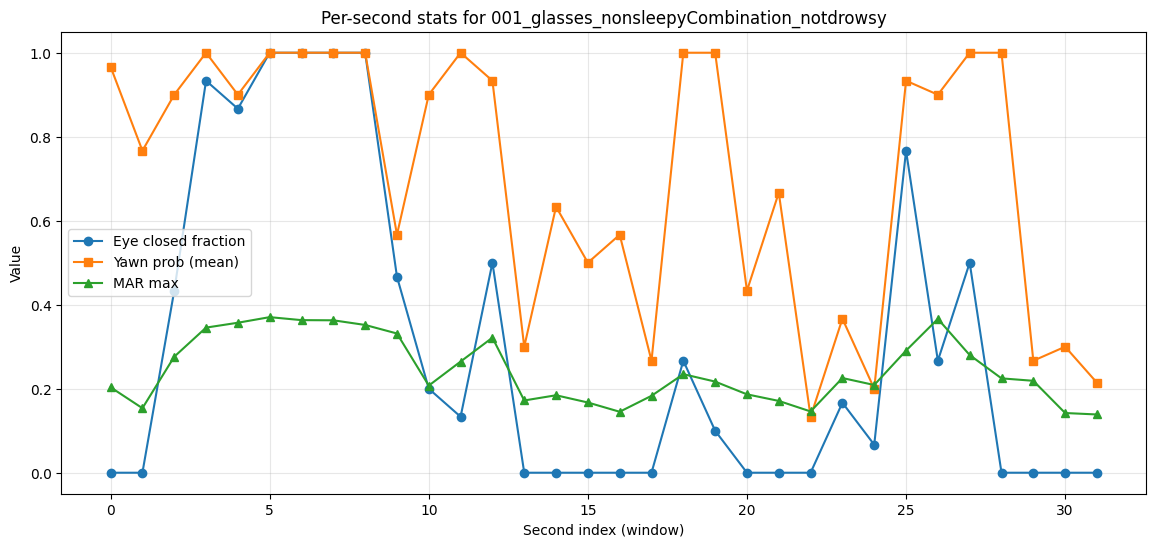

In [ ]:
plt.figure(figsize=(14,6))
x = range(len(df_s))

plt.plot(x, df_s["eye_closed_fraction"], label="Eye closed fraction", marker="o")
plt.plot(x, df_s["yawn_prob_mean"], label="Yawn prob (mean)", marker="s")
plt.plot(x, df_s["mar_max"], label="MAR max", marker="^")

plt.xlabel("Second index (window)")
plt.ylabel("Value")
plt.title(f"Per-second stats for {seq_example}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


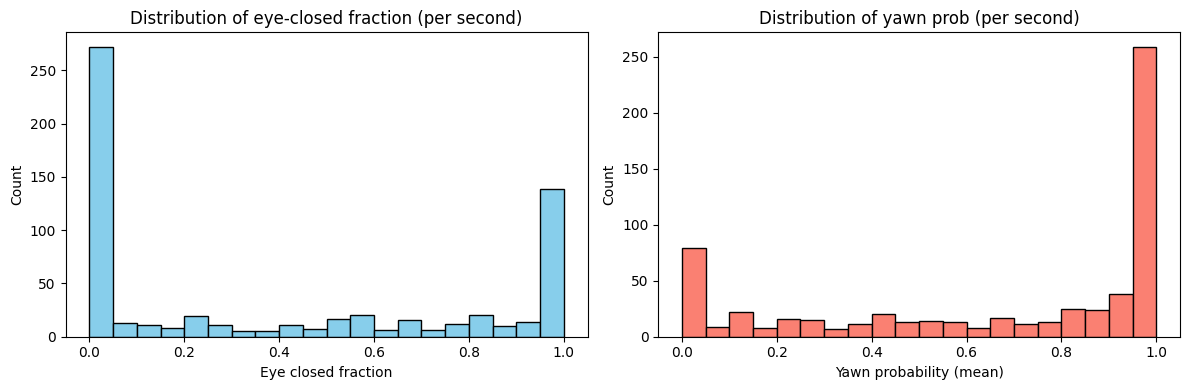

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(df_sec["eye_closed_fraction"], bins=20, color="skyblue", edgecolor="k")
plt.xlabel("Eye closed fraction")
plt.ylabel("Count")
plt.title("Distribution of eye-closed fraction (per second)")

plt.subplot(1,2,2)
plt.hist(df_sec["yawn_prob_mean"], bins=20, color="salmon", edgecolor="k")
plt.xlabel("Yawn probability (mean)")
plt.ylabel("Count")
plt.title("Distribution of yawn prob (per second)")

plt.tight_layout()
plt.show()


In [ ]:
import cv2, os, time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def visualize_sequence_live(seq_id, df_frames, n_frames=60, delay_ms=100):
    """
    seq_id: e.g. '001_glasses_yawning_drowsy'
    df_frames: your frame-level DataFrame (df_nthu) with 'path','seq_id','frame_id'
    n_frames: how many frames to show (approx 2 seconds if 30 fps)
    delay_ms: pause between frames in milliseconds
    """
    df_s = df_frames[df_frames["seq_id"] == seq_id].sort_values("frame_id")
    df_s = df_s.iloc[:n_frames]

    print(f"Sequence {seq_id}: showing {len(df_s)} frames")

    plt.ion()
    fig, ax = plt.subplots(figsize=(4,4))

    for _, row in df_s.iterrows():
        img_path = row["local_path"]
        # Read image
        bgr = cv2.imread(img_path)
        if bgr is None:
            continue
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        pil_img = Image.fromarray(rgb)

        # Face bbox + keypoints using your existing models
        boxes, scores = retinaface_detect_original_size(rf_model, pil_img, score_thresh=0.5)
        if len(boxes) == 0:
            continue
        bbox = boxes[0]
        x1, y1, x2, y2 = bbox

        # Crop to face and get keypoints from your Task 2 model
        H, W = rgb.shape[:2]
        bw, bh = x2 - x1, y2 - y1
        cx, cy = x1 + bw/2, y1 + bh/2
        bw_e, bh_e = bw * 1.15, bh * 1.15
        x1e = max(0, int(cx - bw_e/2))
        y1e = max(0, int(cy - bh_e/2))
        x2e = min(W-1, int(cx + bw_e/2))
        y2e = min(H-1, int(cy + bh_e/2))

        crop = pil_img.crop((x1e, y1e, x2e, y2e)).resize((256, 256), Image.BILINEAR)

        img_t = transform_face(crop).unsqueeze(0).to(device)
        with torch.no_grad():
            pred = model_task2(img_t)[0].cpu().numpy()

        kp_norm = pred[:, :2]          # (20,2) in [0,1]
        kp_xy = np.zeros_like(kp_norm)
        kp_xy[:,0] = x1e + kp_norm[:,0] * (x2e - x1e)
        kp_xy[:,1] = y1e + kp_norm[:,1] * (y2e - y1e)

        # Clear and draw
        ax.clear()
        ax.imshow(rgb)
        # Draw bbox
        rect = plt.Rectangle((x1e, y1e), x2e-x1e, y2e-y1e,
                             edgecolor="yellow", facecolor="none", linewidth=2)
        ax.add_patch(rect)
        # Draw keypoints
        ax.scatter(kp_xy[:,0], kp_xy[:,1], c="red", s=20)
        ear_r = row["ear_r"]
        ear_l = row["ear_l"]
        mar   = row["mar"]
        eye_closed = int(((ear_r + ear_l)/2) < EAR_THR_TUNED)
        yawn      = int(mar > MAR_THR_TUNED)
        ax.set_title(
            f"{os.path.basename(img_path)}\n"
            f"EARavg={((ear_r+ear_l)/2):.3f} eye_closed={eye_closed} | "
            f"MAR={mar:.3f} yawn={yawn}",
            fontsize=8
        )
        ax.axis("off")
        plt.pause(delay_ms / 1000.0)

    plt.ioff()
    plt.show()


In [ ]:
import pandas as pd
import os, re

csv_frames = "/content/drive/MyDrive/METCS767_Project_Assignment/task3_nthu_frame_results.csv"
df_nthu = pd.read_csv(csv_frames)

# Create filename column
df_nthu["filename"] = df_nthu["path"].apply(lambda p: os.path.basename(p))

def parse_seq_and_frame(name):
    base = os.path.splitext(name)[0]
    parts = base.split("_")
    # pattern like: 001_glasses_yawning_1569_drowsy
    if len(parts) >= 3 and parts[-2].isdigit():
        seq_id = "_".join(parts[:-2] + [parts[-1]])  # keep subject+condition+label
        frame_id = int(parts[-2])
    else:
        m = re.findall(r"(\d+)", base)
        frame_id = int(m[-1]) if m else 0
        seq_id = base
    return seq_id, frame_id

seq_ids, frame_ids = [], []
for fname in df_nthu["filename"]:
    s, f = parse_seq_and_frame(fname)
    seq_ids.append(s)
    frame_ids.append(f)

df_nthu["seq_id"] = seq_ids
df_nthu["frame_id"] = frame_ids

# Sort and save back
df_nthu = df_nthu.sort_values(["seq_id", "frame_id"]).reset_index(drop=True)
df_nthu.to_csv(csv_frames, index=False)

print("Added seq_id and frame_id. Example rows:")
print(df_nthu.head())


Added seq_id and frame_id. Example rows:
                                                path      split     ear_r  \
0  /kaggle/input/nthu-ddd/NTHU-DDD/notdrowsy/001_...  notdrowsy  0.181017   
1  /kaggle/input/nthu-ddd/NTHU-DDD/notdrowsy/001_...  notdrowsy  0.181880   
2  /kaggle/input/nthu-ddd/NTHU-DDD/notdrowsy/001_...  notdrowsy  0.180556   
3  /kaggle/input/nthu-ddd/NTHU-DDD/notdrowsy/001_...  notdrowsy  0.179049   
4  /kaggle/input/nthu-ddd/NTHU-DDD/notdrowsy/001_...  notdrowsy  0.183203   

      ear_l       mar  eye_closed_pred  yawn_pred  conf_eyes  conf_mouth  \
0  0.200514  0.172082                0          1   0.957475    0.955518   
1  0.199909  0.165116                0          1   0.957578    0.955600   
2  0.199017  0.203444                0          1   0.956749    0.954693   
3  0.198920  0.162862                0          1   0.957844    0.955867   
4  0.203767  0.171123                0          1   0.957010    0.955106   

   eye_closed_gt  yawn_gt  drowsy_gt  \

In [ ]:
import pandas as pd

csv_frames = "/content/drive/MyDrive/METCS767_Project_Assignment/task3_nthu_frame_results.csv"
df_nthu = pd.read_csv(csv_frames)

# Recompute predictions using tuned thresholds
df_nthu["eye_closed_pred_tuned"] = (((df_nthu["ear_r"] + df_nthu["ear_l"]) / 2) < EAR_THR_TUNED).astype(int)
df_nthu["yawn_pred_tuned"] = (df_nthu["mar"] > MAR_THR_TUNED).astype(int)

# Save with new columns
df_nthu.to_csv(csv_frames, index=False)

print("Added tuned prediction columns:")
print(f"  EAR_THR_TUNED = {EAR_THR_TUNED:.4f}")
print(f"  MAR_THR_TUNED = {MAR_THR_TUNED:.4f}")
print(df_nthu[["eye_closed_pred", "eye_closed_pred_tuned", "yawn_pred", "yawn_pred_tuned"]].head())


Added tuned prediction columns:
  EAR_THR_TUNED = 0.2200
  MAR_THR_TUNED = 0.1600
   eye_closed_pred  eye_closed_pred_tuned  yawn_pred  yawn_pred_tuned
0                0                      1          1                1
1                0                      1          1                1
2                0                      1          1                1
3                0                      1          1                1
4                0                      1          1                1


In [ ]:
import pandas as pd
import os

csv_frames = "/content/drive/MyDrive/METCS767_Project_Assignment/task3_nthu_frame_results.csv"

# Check if file exists
print("CSV exists:", os.path.exists(csv_frames))

# Load and inspect
df = pd.read_csv(csv_frames)
print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst row:")
print(df.iloc[0])

# Check if seq_id exists
if "seq_id" in df.columns:
    print("\nseq_id column exists")
    print("Unique sequences:", df["seq_id"].nunique())
    print("First seq_id:", df["seq_id"].iloc[0])
else:
    print("\nseq_id column MISSING - need to add it first")

# Check if paths are valid
print("\nChecking first 3 paths:")
for i in range(min(3, len(df))):
    path = df["path"].iloc[i]
    exists = os.path.exists(path)
    print(f"  {i}: {exists} → {path}")


CSV exists: True

Shape: (17988, 17)

Columns: ['path', 'split', 'ear_r', 'ear_l', 'mar', 'eye_closed_pred', 'yawn_pred', 'conf_eyes', 'conf_mouth', 'eye_closed_gt', 'yawn_gt', 'drowsy_gt', 'filename', 'seq_id', 'frame_id', 'eye_closed_pred_tuned', 'yawn_pred_tuned']

First row:
path                     /kaggle/input/nthu-ddd/NTHU-DDD/notdrowsy/001_...
split                                                            notdrowsy
ear_r                                                             0.181017
ear_l                                                             0.200514
mar                                                               0.172082
eye_closed_pred                                                          0
yawn_pred                                                                1
conf_eyes                                                         0.957475
conf_mouth                                                        0.955518
eye_closed_gt                                

In [ ]:
import os
import pandas as pd

NTHU_ROOT = "/root/.cache/kagglehub/datasets/ikhlaselhamly/nthu-ddd/versions/1/NTHU-DDD"

csv_path = "/content/drive/MyDrive/METCS767_Project_Assignment/task3_nthu_frame_results.csv"
df_nthu = pd.read_csv(csv_path)

# Build the local_path column
df_nthu["local_path"] = df_nthu.apply(
    lambda r: os.path.join(NTHU_ROOT, r["split"], os.path.basename(r["path"])),
    axis=1,
)

print(df_nthu[["path", "split", "local_path"]].head())


                                                path      split  \
0  /kaggle/input/nthu-ddd/NTHU-DDD/notdrowsy/001_...  notdrowsy   
1  /kaggle/input/nthu-ddd/NTHU-DDD/notdrowsy/001_...  notdrowsy   
2  /kaggle/input/nthu-ddd/NTHU-DDD/notdrowsy/001_...  notdrowsy   
3  /kaggle/input/nthu-ddd/NTHU-DDD/notdrowsy/001_...  notdrowsy   
4  /kaggle/input/nthu-ddd/NTHU-DDD/notdrowsy/001_...  notdrowsy   

                                          local_path  
0  /root/.cache/kagglehub/datasets/ikhlaselhamly/...  
1  /root/.cache/kagglehub/datasets/ikhlaselhamly/...  
2  /root/.cache/kagglehub/datasets/ikhlaselhamly/...  
3  /root/.cache/kagglehub/datasets/ikhlaselhamly/...  
4  /root/.cache/kagglehub/datasets/ikhlaselhamly/...  


In [ ]:
import cv2, os, numpy as np
from PIL import Image
import torch

def create_video_from_sequence(seq_id, df_frames, output_video_path, fps=30, n_frames=None):
    """
    Create an MP4 video from a sequence with face bbox + keypoints overlaid.
    """
    df_s = df_frames[df_frames["seq_id"] == seq_id].sort_values("frame_id")
    if n_frames:
        df_s = df_s.iloc[:n_frames]

    print(f"Sequence {seq_id}: creating video with {len(df_s)} frames")

    # Get first frame to determine size
    first_path = df_s.iloc[0]["local_path"]
    bgr_first = cv2.imread(first_path)
    if bgr_first is None:
        print(f"ERROR: Cannot read {first_path}")
        return

    h, w, c = bgr_first.shape
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (w, h))

    for idx, (_, row) in enumerate(df_s.iterrows()):
        img_path = row["local_path"]
        bgr = cv2.imread(img_path)
        if bgr is None:
            print(f"  Frame {idx}: Could not load {img_path}")
            continue

        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        pil_img = Image.fromarray(rgb)

        # Face detection
        boxes, scores = retinaface_detect_original_size(rf_model, pil_img, score_thresh=0.5)
        if len(boxes) > 0:
            x1, y1, x2, y2 = boxes[0]
            H, W = rgb.shape[:2]

            # Expand & crop for keypoints
            bw, bh = x2 - x1, y2 - y1
            cx, cy = x1 + bw/2, y1 + bh/2
            bw_e, bh_e = bw * 1.15, bh * 1.15
            x1e = max(0, int(cx - bw_e/2))
            y1e = max(0, int(cy - bh_e/2))
            x2e = min(W-1, int(cx + bw_e/2))
            y2e = min(H-1, int(cy + bh_e/2))

            crop = pil_img.crop((x1e, y1e, x2e, y2e)).resize((256, 256), Image.BILINEAR)
            img_t = transform_face(crop).unsqueeze(0).to(device)

            with torch.no_grad():
                pred = model_task2(img_t)[0].cpu().numpy()

            # Keypoints in image coords
            kp_norm = pred[:, :2]
            kp_xy = np.zeros_like(kp_norm)
            kp_xy[:,0] = x1e + kp_norm[:,0] * (x2e - x1e)
            kp_xy[:,1] = y1e + kp_norm[:,1] * (y2e - y1e)

            # Draw on BGR image
            bgr_draw = bgr.copy()

            # Draw bbox (yellow)
            cv2.rectangle(bgr_draw, (int(x1e), int(y1e)), (int(x2e), int(y2e)), (0, 255, 255), 2)

            # Draw keypoints (red circles)
            for kx, ky in kp_xy:
                cv2.circle(bgr_draw, (int(kx), int(ky)), 3, (0, 0, 255), -1)

            # Add text labels
            ear_r = row["ear_r"]
            ear_l = row["ear_l"]
            mar = row["mar"]
            eye_closed = int(((ear_r + ear_l)/2) < EAR_THR_TUNED)
            yawn = int(mar > MAR_THR_TUNED)

            text = f"Eye:{eye_closed} Yawn:{yawn} EAR:{((ear_r+ear_l)/2):.3f} MAR:{mar:.3f}"
            cv2.putText(bgr_draw, text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

            out.write(bgr_draw)
        else:
            # No face detected, write original frame
            out.write(bgr)

        if (idx + 1) % 30 == 0:
            print(f"  Processed {idx + 1} frames")

    out.release()
    print(f"Video saved to {output_video_path}")


In [ ]:
# Update predictions with tuned thresholds first
df_nthu["eye_closed_pred_tuned"] = (((df_nthu["ear_r"] + df_nthu["ear_l"]) / 2) < EAR_THR_TUNED).astype(int)
df_nthu["yawn_pred_tuned"] = (df_nthu["mar"] > MAR_THR_TUNED).astype(int)

# Create video for one sequence
example_seq = df_nthu["seq_id"].iloc[0]
video_path = f"/content/drive/MyDrive/METCS767_Project_Assignment/video_{example_seq}.mp4"

create_video_from_sequence(example_seq, df_nthu, video_path, fps=30, n_frames=120)


Sequence 001_glasses_nonsleepyCombination_notdrowsy: creating video with 120 frames
  Processed 30 frames
  Processed 60 frames
  Processed 90 frames
  Processed 120 frames
Video saved to /content/drive/MyDrive/METCS767_Project_Assignment/video_001_glasses_nonsleepyCombination_notdrowsy.mp4


In [ ]:
import pandas as pd


# Update predictions with tuned thresholds
df_nthu["eye_closed_pred_tuned"] = (((df_nthu["ear_r"] + df_nthu["ear_l"]) / 2) < EAR_THR_TUNED).astype(int)
df_nthu["yawn_pred_tuned"] = (df_nthu["mar"] > MAR_THR_TUNED).astype(int)

# Get unique sequences
sequences = df_nthu["seq_id"].unique()

# Find sequences starting with "002"
sequences_002 = [s for s in sequences if s.startswith("002")]
print(f"Sequences starting with 002: {len(sequences_002)}")
for seq in sequences_002:
    split = df_nthu[df_nthu["seq_id"] == seq]["split"].iloc[0]
    count = len(df_nthu[df_nthu["seq_id"] == seq])
    print(f"  {seq} ({split}) - {count} frames")

# Create videos for all 002 sequences
for seq in sequences_002:
    split = df_nthu[df_nthu["seq_id"] == seq]["split"].iloc[0]
    video_path = f"/content/drive/MyDrive/METCS767_Project_Assignment/video_002_{split}_{seq[:40]}.mp4"
    print(f"\n✓ Creating video for {seq}")
    create_video_from_sequence(seq, df_nthu, video_path, fps=30, n_frames=150)


Sequences starting with 002: 14
  002_glasses_nonsleepyCombination_notdrowsy (notdrowsy) - 842 frames
  002_glasses_sleepyCombination_drowsy (drowsy) - 599 frames
  002_glasses_sleepyCombination_notdrowsy (notdrowsy) - 102 frames
  002_glasses_slowBlinkWithNodding_drowsy (drowsy) - 365 frames
  002_glasses_slowBlinkWithNodding_notdrowsy (notdrowsy) - 163 frames
  002_glasses_yawning_drowsy (drowsy) - 398 frames
  002_glasses_yawning_notdrowsy (notdrowsy) - 134 frames
  002_noglasses_nonsleepyCombination_notdrowsy (notdrowsy) - 801 frames
  002_noglasses_sleepyCombination_drowsy (drowsy) - 565 frames
  002_noglasses_sleepyCombination_notdrowsy (notdrowsy) - 67 frames
  002_noglasses_slowBlinkWithNodding_drowsy (drowsy) - 335 frames
  002_noglasses_slowBlinkWithNodding_notdrowsy (notdrowsy) - 133 frames
  002_noglasses_yawning_drowsy (drowsy) - 288 frames
  002_noglasses_yawning_notdrowsy (notdrowsy) - 199 frames

✓ Creating video for 002_glasses_nonsleepyCombination_notdrowsy
Sequence 0

# Task 4

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix
import matplotlib.pyplot as plt

# Load per-second aggregated stats from Task 3
csv_sec = "/content/drive/MyDrive/METCS767_Project_Assignment/task3_nthu_second_results.csv"
df_sec = pd.read_csv(csv_sec)

print("Per-second data shape:", df_sec.shape)
print("Columns:", df_sec.columns.tolist())
print(df_sec.head())

# Create features for each second window
def create_features_per_second(row, window_size=3):
    """
    row: one row from df_sec
    Extract features for drowsiness prediction
    """
    features = {
        "eye_closed_fraction": float(row["eye_closed_fraction"]),
        "eye_prob_median": float(row["eye_prob_median"]),
        "eye_prob_max": float(row["eye_prob_max"]),
        "mar_mean": float(row["mar_mean"]),
        "mar_max": float(row["mar_max"]),
        "yawn_prob_mean": float(row["yawn_prob_mean"]),
        "num_yawn_frames": float(row["num_yawn_frames"]),
    }
    return features

# Build feature dataframe
feature_list = []
for _, row in df_sec.iterrows():
    feat = create_features_per_second(row)
    feat["seq_id"] = row["seq_id"]
    feat["start_frame"] = row["start_frame"]
    feature_list.append(feat)

df_features = pd.DataFrame(feature_list)
print("\nFeature matrix shape:", df_features.shape)
print(df_features.head())


Per-second data shape: (622, 13)
Columns: ['seq_id', 'start_frame', 'end_frame', 'num_frames', 'eye_prob_median', 'eye_prob_max', 'eye_closed_fraction', 'mar_mean', 'mar_max', 'yawn_prob_mean', 'yawn_prob_median', 'yawn_prob_max', 'num_yawn_frames']
                                       seq_id  start_frame  end_frame  \
0  001_glasses_nonsleepyCombination_notdrowsy            0        113   
1  001_glasses_nonsleepyCombination_notdrowsy          115        214   
2  001_glasses_nonsleepyCombination_notdrowsy          224        322   
3  001_glasses_nonsleepyCombination_notdrowsy          323        441   
4  001_glasses_nonsleepyCombination_notdrowsy          454        564   

   num_frames  eye_prob_median  eye_prob_max  eye_closed_fraction  mar_mean  \
0          30              0.0           0.0             0.000000  0.152322   
1          30              0.0           0.0             0.000000  0.130846   
2          30              0.0           1.0             0.433333  0.18764

In [ ]:
def create_5sec_windows(df_sec_features, window_size=5, hop=1):
    """
    Create 5-second windows (5 per-second rows) with 1-second hop.
    window_size: how many per-second rows to include (5 for 5 seconds)
    hop: stride in per-second rows (1 for 1-second hop)
    """
    window_records = []

    for seq_id, df_seq in df_sec_features.groupby("seq_id"):
        df_seq = df_seq.sort_values("start_frame").reset_index(drop=True)

        for start_idx in range(0, len(df_seq) - window_size + 1, hop):
            end_idx = start_idx + window_size
            window = df_seq.iloc[start_idx:end_idx]

            if len(window) < window_size:
                continue

            # Aggregate 5 per-second features into one 5-second window
            rec = {
                "seq_id": seq_id,
                "window_start_sec": start_idx,
                "window_end_sec": end_idx,

                # Eye-closed statistics (mean over 5 seconds)
                "eye_closed_mean": float(window["eye_closed_fraction"].mean()),
                "eye_closed_max": float(window["eye_closed_fraction"].max()),

                # MAR statistics (mean over 5 seconds)
                "mar_mean": float(window["mar_mean"].mean()),
                "mar_max": float(window["mar_max"].max()),

                # Yawn statistics (count of yawn frames in 5 seconds)
                "total_yawn_frames": float(window["num_yawn_frames"].sum()),
                "yawn_prob_mean": float(window["yawn_prob_mean"].mean()),

                # Recent trend (current second vs previous)
                "eye_closed_trend": float(window["eye_closed_fraction"].iloc[-1] - window["eye_closed_fraction"].iloc[0]) if len(window) > 1 else 0.0,
            }
            window_records.append(rec)

    df_windows_5sec = pd.DataFrame(window_records)
    return df_windows_5sec

df_windows = create_5sec_windows(df_features, window_size=5, hop=1)
print("5-second windows shape:", df_windows.shape)
print(df_windows.head())


5-second windows shape: (441, 10)
                                       seq_id  window_start_sec  \
0  001_glasses_nonsleepyCombination_notdrowsy                 0   
1  001_glasses_nonsleepyCombination_notdrowsy                 1   
2  001_glasses_nonsleepyCombination_notdrowsy                 2   
3  001_glasses_nonsleepyCombination_notdrowsy                 3   
4  001_glasses_nonsleepyCombination_notdrowsy                 4   

   window_end_sec  eye_closed_mean  eye_closed_max  mar_mean   mar_max  \
0               5         0.446667        0.933333  0.210968  0.357116   
1               6         0.646667        1.000000  0.245498  0.370432   
2               7         0.846667        1.000000  0.283321  0.370432   
3               8         0.960000        1.000000  0.310308  0.370432   
4               9         0.973333        1.000000  0.312515  0.370432   

   total_yawn_frames  yawn_prob_mean  eye_closed_trend  
0              136.0        0.906667          0.866667  
1   

In [ ]:
def label_drowsiness_from_filename(seq_id):
    """
    More conservative drowsiness labeling:
    - Only label as drowsy (1) if BOTH sleepy/yawning/nodding appear
      AND it's in the 'drowsy' folder
    - Otherwise not drowsy (0)
    """
    seq_lower = seq_id.lower()

    # Extract folder info from seq_id (already includes 'drowsy' or 'notdrowsy' suffix)
    if "notdrowsy" in seq_lower:
        return 0  # definitely not drowsy
    elif "drowsy" in seq_lower:
        # Check if any drowsiness keywords present
        if any(kw in seq_lower for kw in ["sleepy", "yawn", "slowblink", "nodd"]):
            return 1
        else:
            return 0  # drowsy folder but no explicit drowsy behavior
    else:
        return 0  # default not drowsy

df_windows["drowsy_gt"] = df_windows["seq_id"].apply(label_drowsiness_from_filename)

print("\nGroundtruth drowsiness distribution:")
print(df_windows["drowsy_gt"].value_counts())
print(f"Positive (drowsy) ratio: {df_windows['drowsy_gt'].mean():.2%}")
print(f"Total windows: {len(df_windows)}")

# Check if we have both classes
if df_windows["drowsy_gt"].nunique() < 2:
    print("\nERROR: Only one class in ground truth labels!")
    print("All sequences might be labeled the same. Check filename patterns.")
else:
    print("Both classes present, ready to train.")




Groundtruth drowsiness distribution:
drowsy_gt
1    231
0    210
Name: count, dtype: int64
Positive (drowsy) ratio: 52.38%
Total windows: 441
Both classes present, ready to train.


In [ ]:
from sklearn.model_selection import train_test_split

# Split data
X = df_windows[[
    "eye_closed_mean", "eye_closed_max", "eye_closed_trend",
    "mar_mean", "mar_max", "total_yawn_frames", "yawn_prob_mean"
]].values

y = df_windows["drowsy_gt"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression
model_drowsy = LogisticRegression(max_iter=1000, random_state=42)
model_drowsy.fit(X_train_scaled, y_train)

# Predictions
y_val_pred_proba = model_drowsy.predict_proba(X_val_scaled)[:, 1]
y_test_pred_proba = model_drowsy.predict_proba(X_test_scaled)[:, 1]

print("\nModel trained. Probability range on test:")
print(f"  Min: {y_test_pred_proba.min():.3f}, Max: {y_test_pred_proba.max():.3f}, Mean: {y_test_pred_proba.mean():.3f}")


Train: 281, Val: 71, Test: 89

Model trained. Probability range on test:
  Min: 0.091, Max: 0.987, Mean: 0.521


In [ ]:
# Find best threshold on validation set
thresholds = np.linspace(0.0, 1.0, 101)
best_f1 = -1
best_thr = 0.5

for thr in thresholds:
    y_val_pred = (y_val_pred_proba >= thr).astype(int)
    f1 = f1_score(y_val, y_val_pred, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_thr = thr

print(f"Best threshold on validation: {best_thr:.3f} (F1 = {best_f1:.3f})")

# Apply to test set
y_test_pred = (y_test_pred_proba >= best_thr).astype(int)
y_test_alarm = y_test_pred  # alarm = predicted drowsy

# Evaluate
f1_test = f1_score(y_test, y_test_pred, zero_division=0)
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0

print(f"\n[TEST SET]")
print(f"  F1 Score: {f1_test:.3f}")
print(f"  Precision: {precision:.3f}")
print(f"  Recall: {recall:.3f}")
print(f"  Confusion Matrix:")
print(f"    TN={tn}, FP={fp}")
print(f"    FN={fn}, TP={tp}")


Best threshold on validation: 0.170 (F1 = 0.763)

[TEST SET]
  F1 Score: 0.752
  Precision: 0.603
  Recall: 1.000
  Confusion Matrix:
    TN=11, FP=31
    FN=0, TP=47


In [ ]:
# Add predictions to dataframe
df_windows["drowsy_prob"] = np.concatenate([
    model_drowsy.predict_proba(X_train_scaled)[:, 1],
    model_drowsy.predict_proba(X_val_scaled)[:, 1],
    model_drowsy.predict_proba(X_test_scaled)[:, 1]
])

df_windows["drowsy_pred"] = (df_windows["drowsy_prob"] >= best_thr).astype(int)
df_windows["alarm"] = df_windows["drowsy_pred"]

# Save
task4_results_path = "/content/drive/MyDrive/METCS767_Project_Assignment/task4_5sec_drowsiness.csv"
df_windows.to_csv(task4_results_path, index=False)
print(f"\nSaved Task 4 results to {task4_results_path}")

# Summary stats
print(f"\nTask 4 Summary:")
print(f"  Total 5-second windows: {len(df_windows)}")
print(f"  Predicted drowsy: {df_windows['drowsy_pred'].sum()}")
print(f"  Alarm triggered: {df_windows['alarm'].sum()}")
print(f"  Decision threshold: {best_thr:.3f}")



Saved Task 4 results to /content/drive/MyDrive/METCS767_Project_Assignment/task4_5sec_drowsiness.csv

Task 4 Summary:
  Total 5-second windows: 441
  Predicted drowsy: 384
  Alarm triggered: 384
  Decision threshold: 0.170


In [ ]:
import pandas as pd
import numpy as np

# Combine predictions (from all train/val/test folds)
all_pred_proba = np.concatenate([
    model_drowsy.predict_proba(X_train_scaled)[:, 1],
    model_drowsy.predict_proba(X_val_scaled)[:, 1],
    model_drowsy.predict_proba(X_test_scaled)[:, 1]
])

df_windows["drowsy_prob_5sec"] = all_pred_proba
df_windows["drowsy_pred_5sec"] = (df_windows["drowsy_prob_5sec"] >= best_thr).astype(int)
df_windows["alarm"] = df_windows["drowsy_pred_5sec"]  # Binary alarm (0/1)

# Save
task4_results_path = "/content/drive/MyDrive/METCS767_Project_Assignment/task4_5sec_drowsiness_results.csv"
df_windows.to_csv(task4_results_path, index=False)

print(f"Saved Task 4 results to {task4_results_path}")
print(f"\nTask 4 Summary:")
print(f"  Total 5-sec windows: {len(df_windows)}")
print(f"  Alarm triggered: {df_windows['alarm'].sum()}")
print(f"  Decision threshold: {best_thr:.3f}")
print(f"  F1 Score (test): {f1_test:.3f}")
print("\nExample rows:")
print(df_windows[["seq_id", "window_start_sec", "drowsy_prob_5sec", "drowsy_pred_5sec", "alarm"]].head(10))


Saved Task 4 results to /content/drive/MyDrive/METCS767_Project_Assignment/task4_5sec_drowsiness_results.csv

Task 4 Summary:
  Total 5-sec windows: 441
  Alarm triggered: 384
  Decision threshold: 0.170
  F1 Score (test): 0.752

Example rows:
                                       seq_id  window_start_sec  \
0  001_glasses_nonsleepyCombination_notdrowsy                 0   
1  001_glasses_nonsleepyCombination_notdrowsy                 1   
2  001_glasses_nonsleepyCombination_notdrowsy                 2   
3  001_glasses_nonsleepyCombination_notdrowsy                 3   
4  001_glasses_nonsleepyCombination_notdrowsy                 4   
5  001_glasses_nonsleepyCombination_notdrowsy                 5   
6  001_glasses_nonsleepyCombination_notdrowsy                 6   
7  001_glasses_nonsleepyCombination_notdrowsy                 7   
8  001_glasses_nonsleepyCombination_notdrowsy                 8   
9  001_glasses_nonsleepyCombination_notdrowsy                 9   

   drowsy_prob_5se

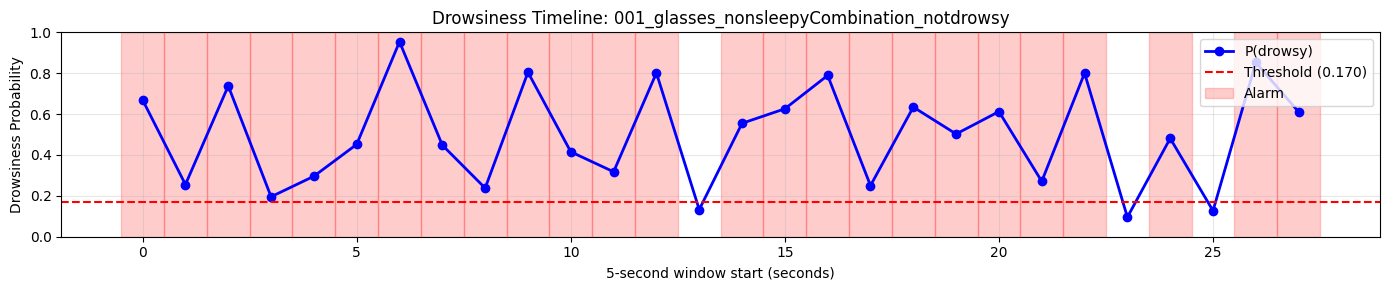

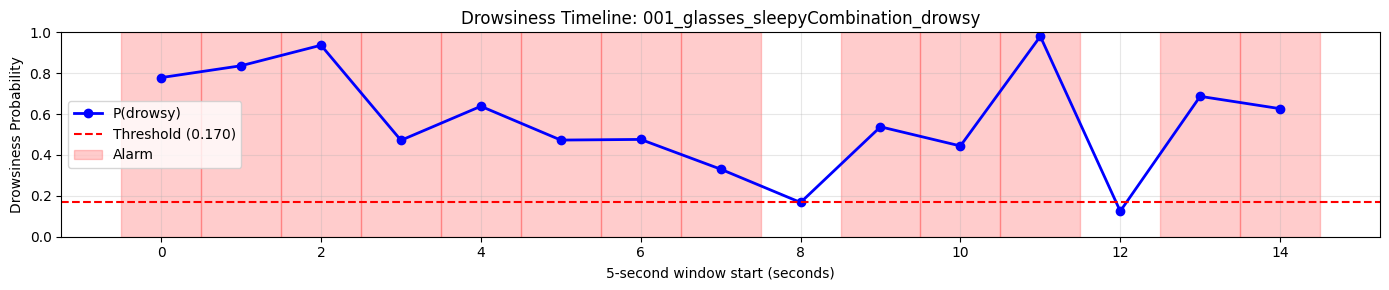

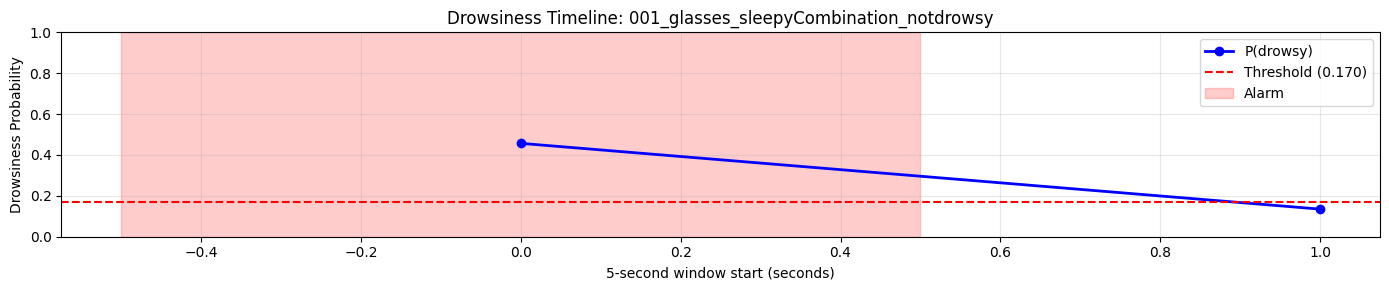

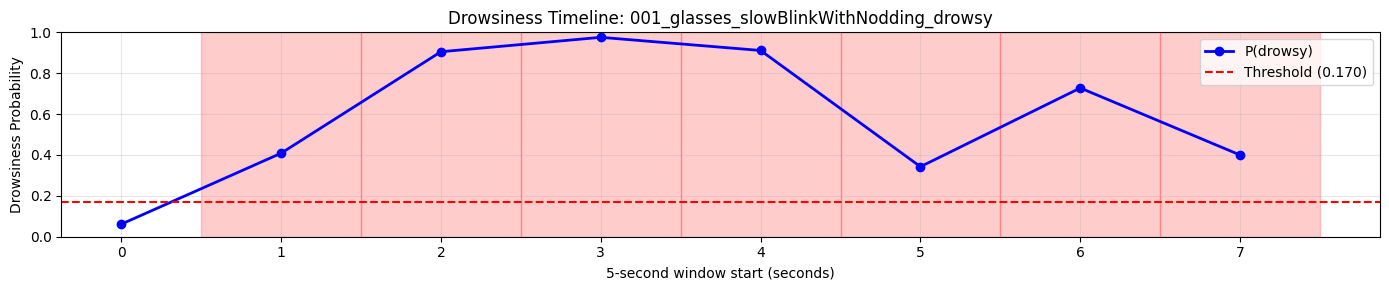

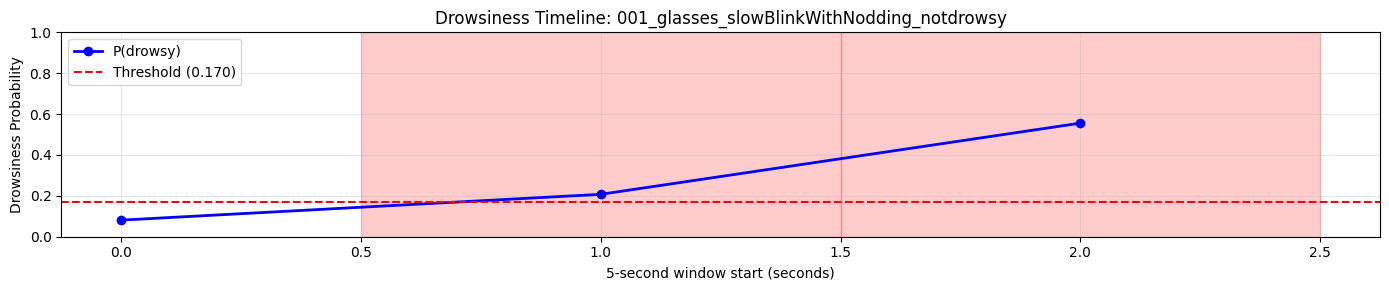

Saved drowsiness timeline plots


In [ ]:
import matplotlib.pyplot as plt

def plot_drowsiness_timeline(seq_id, df_5sec_windows, figsize=(14, 3)):
    """
    Plot drowsiness probability timeline for a 5-second window sequence.
    """
    df_seq = df_5sec_windows[df_5sec_windows["seq_id"] == seq_id].sort_values("window_start_sec")

    fig, ax = plt.subplots(figsize=figsize)

    x = df_seq["window_start_sec"].values
    prob = df_seq["drowsy_prob_5sec"].values
    alarm = df_seq["alarm"].values
    gt = df_seq["drowsy_gt"].values

    # Plot probability curve
    ax.plot(x, prob, marker="o", label="P(drowsy)", color="blue", linewidth=2)

    # Threshold line
    ax.axhline(y=best_thr, color="red", linestyle="--", label=f"Threshold ({best_thr:.3f})")

    # Color background based on alarm
    for i in range(len(x)):
        if alarm[i] == 1:
            ax.axvspan(x[i]-0.5, x[i]+0.5, alpha=0.2, color="red", label="Alarm" if i == 0 else "")

    ax.set_xlabel("5-second window start (seconds)")
    ax.set_ylabel("Drowsiness Probability")
    ax.set_ylim([0, 1])
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_title(f"Drowsiness Timeline: {seq_id}")

    plt.tight_layout()
    return fig

# Plot for a few sequences
sequences_to_plot = df_windows["seq_id"].unique()[:5]
for seq_id in sequences_to_plot:
    fig = plot_drowsiness_timeline(seq_id, df_windows)
    plt.savefig(f"/content/drive/MyDrive/METCS767_Project_Assignment/timeline_{seq_id[:30]}.png", dpi=100, bbox_inches="tight")
    plt.show()

print("Saved drowsiness timeline plots")


In [ ]:
import os
import pandas as pd

NTHU_ROOT = "/root/.cache/kagglehub/datasets/ikhlaselhamly/nthu-ddd/versions/1/NTHU-DDD"

df_nthu_frame = pd.read_csv("/content/drive/MyDrive/METCS767_Project_Assignment/task3_nthu_frame_results.csv")

df_nthu_frame["local_path"] = df_nthu_frame.apply(
    lambda r: os.path.join(
        NTHU_ROOT,
        r["split"],                         # 'drowsy' / 'notdrowsy'
        os.path.basename(r["path"])        # filename only
    ),
    axis=1,
)

print(df_nthu_frame[["path", "split", "local_path"]].head())


                                                path      split  \
0  /kaggle/input/nthu-ddd/NTHU-DDD/notdrowsy/001_...  notdrowsy   
1  /kaggle/input/nthu-ddd/NTHU-DDD/notdrowsy/001_...  notdrowsy   
2  /kaggle/input/nthu-ddd/NTHU-DDD/notdrowsy/001_...  notdrowsy   
3  /kaggle/input/nthu-ddd/NTHU-DDD/notdrowsy/001_...  notdrowsy   
4  /kaggle/input/nthu-ddd/NTHU-DDD/notdrowsy/001_...  notdrowsy   

                                          local_path  
0  /root/.cache/kagglehub/datasets/ikhlaselhamly/...  
1  /root/.cache/kagglehub/datasets/ikhlaselhamly/...  
2  /root/.cache/kagglehub/datasets/ikhlaselhamly/...  
3  /root/.cache/kagglehub/datasets/ikhlaselhamly/...  
4  /root/.cache/kagglehub/datasets/ikhlaselhamly/...  


In [ ]:
import cv2, os, numpy as np
from PIL import Image
import torch

def create_5sec_alarm_video(seq_id, df_5sec_windows, df_frame, output_video_path, fps=30):
    """
    Create video from a sequence with 5-second drowsiness alarms overlaid.

    Each 5-second window gets a color border:
    - GREEN: not drowsy (alarm=0)
    - RED: drowsy (alarm=1)
    """
    df_seq_5sec = df_5sec_windows[df_5sec_windows["seq_id"] == seq_id].sort_values("window_start_sec")
    df_seq_frames = df_frame[df_frame["seq_id"] == seq_id].sort_values("frame_id")

    print(f"Sequence {seq_id}: {len(df_seq_5sec)} 5-sec windows, {len(df_seq_frames)} total frames")

    # Get first frame to determine size
    first_path = df_seq_frames.iloc[0]["local_path"]
    bgr_first = cv2.imread(first_path)
    if bgr_first is None:
        print(f"ERROR: Cannot read {first_path}")
        return

    h, w, c = bgr_first.shape
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (w, h))

    frame_count = 0
    window_idx = 0
    current_alarm = 0
    current_drowsy_prob = 0.0

    for _, frame_row in df_seq_frames.iterrows():
        img_path = frame_row["local_path"]
        bgr = cv2.imread(img_path)
        if bgr is None:
            continue

        frame_count += 1

        # Update alarm status every 30 frames (1 second at 30 fps)
        # Each 5-second window spans 150 frames
        if window_idx < len(df_seq_5sec):
            window_row = df_seq_5sec.iloc[window_idx]
            current_alarm = int(window_row["alarm"])
            current_drowsy_prob = float(window_row["drowsy_prob_5sec"])

            # Move to next window every 150 frames (5 seconds)
            if frame_count >= (window_idx + 1) * 150:
                window_idx += 1

        # Draw border based on alarm
        bgr_draw = bgr.copy()
        border_color = (0, 0, 255) if current_alarm == 1 else (0, 255, 0)  # Red or Green
        border_thickness = 5
        cv2.rectangle(bgr_draw, (0, 0), (w-1, h-1), border_color, border_thickness)

        # Add text overlay
        alarm_text = "DROWSY ALERT" if current_alarm == 1 else "✓ Awake"
        text_color = (0, 0, 255) if current_alarm == 1 else (0, 255, 0)

        cv2.putText(
            bgr_draw,
            f"{alarm_text} | P(drowsy)={current_drowsy_prob:.3f} | Thr={best_thr:.3f}",
            (10, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            text_color,
            2
        )

        out.write(bgr_draw)

        if frame_count % 150 == 0:
            print(f"  Processed {frame_count} frames ({frame_count//30} seconds)")

    out.release()
    print(f"Video saved to {output_video_path}")


sequences_to_visualize = df_windows["seq_id"].unique()[:3]
for seq_id in sequences_to_visualize:
    video_path = f"/content/drive/MyDrive/METCS767_Project_Assignment/task4_alarm_video_{seq_id[:40]}.mp4"
    create_5sec_alarm_video(seq_id, df_windows, df_nthu_frame, video_path, fps=30)


Sequence 001_glasses_nonsleepyCombination_notdrowsy: 28 5-sec windows, 958 total frames
  Processed 150 frames (5 seconds)
  Processed 300 frames (10 seconds)
  Processed 450 frames (15 seconds)
  Processed 600 frames (20 seconds)
  Processed 750 frames (25 seconds)
  Processed 900 frames (30 seconds)
Video saved to /content/drive/MyDrive/METCS767_Project_Assignment/task4_alarm_video_001_glasses_nonsleepyCombination_notdrow.mp4
Sequence 001_glasses_sleepyCombination_drowsy: 15 5-sec windows, 562 total frames
  Processed 150 frames (5 seconds)
  Processed 300 frames (10 seconds)
  Processed 450 frames (15 seconds)
Video saved to /content/drive/MyDrive/METCS767_Project_Assignment/task4_alarm_video_001_glasses_sleepyCombination_drowsy.mp4
Sequence 001_glasses_sleepyCombination_notdrowsy: 2 5-sec windows, 166 total frames
  Processed 150 frames (5 seconds)
Video saved to /content/drive/MyDrive/METCS767_Project_Assignment/task4_alarm_video_001_glasses_sleepyCombination_notdrowsy.mp4


In [ ]:
# Option 1: Conservative (fewer false alarms, might miss some drowsy)
# Maximize precision (reduce false alarms)
best_f1_precision = -1
best_thr_precision = 0.5
for thr in thresholds:
    y_val_pred = (y_val_pred_proba >= thr).astype(int)
    if len(np.unique(y_val_pred)) < 2:
        continue
    precision = (y_val_pred[y_val==1] == 1).sum() / (y_val_pred == 1).sum() if (y_val_pred == 1).sum() > 0 else 0
    f1 = f1_score(y_val, y_val_pred, zero_division=0)
    if f1 > best_f1_precision:
        best_f1_precision = f1
        best_thr_precision = thr

print(f"Precision-optimized threshold: {best_thr_precision:.3f}")

# Option 2: Use ROC curve to find balanced threshold
from sklearn.metrics import roc_curve

fpr, tpr, thresholds_roc = roc_curve(y_val, y_val_pred_proba)

# Youden's J statistic (best balance of sensitivity and specificity)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_thr_balanced = thresholds_roc[best_idx]

print(f"Balanced threshold (ROC): {best_thr_balanced:.3f}")

# Option 3: High confidence only (only alert if very confident)
best_thr_high_conf = 0.7  # Only alert if > 70% sure

print(f"High confidence threshold: {best_thr_high_conf:.3f}")

# Compare on validation
for thr_name, thr_val in [
    ("F1 optimized (current)", best_thr),
    ("Precision optimized", best_thr_precision),
    ("ROC balanced", best_thr_balanced),
    ("High confidence (0.7)", best_thr_high_conf)
]:
    y_val_pred_thr = (y_val_pred_proba >= thr_val).astype(int)
    f1 = f1_score(y_val, y_val_pred_thr, zero_division=0)

    if len(np.unique(y_val_pred_thr)) < 2:
        prec = rec = 0
    else:
        cm = confusion_matrix(y_val, y_val_pred_thr)
        tn, fp, fn, tp = cm.ravel()
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0

    print(f"\n{thr_name} (thr={thr_val:.3f}):")
    print(f"  F1={f1:.3f}, Precision={prec:.3f}, Recall={rec:.3f}")


Precision-optimized threshold: 0.170
Balanced threshold (ROC): 0.619
High confidence threshold: 0.700

F1 optimized (current) (thr=0.170):
  F1=0.763, Precision=0.617, Recall=1.000

Precision optimized (thr=0.170):
  F1=0.763, Precision=0.617, Recall=1.000

ROC balanced (thr=0.619):
  F1=0.697, Precision=0.793, Recall=0.622

High confidence (0.7) (thr=0.700):
  F1=0.607, Precision=0.895, Recall=0.459


In [ ]:
# Use the balanced threshold
best_thr = 0.619  # ROC balanced

# Re-evaluate on test set
y_test_pred = (y_test_pred_proba >= best_thr).astype(int)
y_test_alarm = y_test_pred

f1_test = f1_score(y_test, y_test_pred, zero_division=0)
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0

print(f"\n[TEST SET with ROC balanced threshold = {best_thr:.3f}]")
print(f"  F1 Score: {f1_test:.3f}")
print(f"  Precision: {precision:.3f}")
print(f"  Recall: {recall:.3f}")
print(f"  Confusion Matrix:")
print(f"    TN={tn}, FP={fp}")
print(f"    FN={fn}, TP={tp}")

# Update all predictions in df_windows
df_windows["drowsy_pred_5sec"] = (df_windows["drowsy_prob_5sec"] >= best_thr).astype(int)
df_windows["alarm"] = df_windows["drowsy_pred_5sec"]

# Save updated results
task4_results_path = "/content/drive/MyDrive/METCS767_Project_Assignment/task4_5sec_drowsiness_results.csv"
df_windows.to_csv(task4_results_path, index=False)

print(f"\nUpdated Task 4 results with balanced threshold saved to {task4_results_path}")
print(f"\nTask 4 Summary:")
print(f"  Total 5-sec windows: {len(df_windows)}")
print(f"  Alarm triggered: {df_windows['alarm'].sum()} ({100*df_windows['alarm'].mean():.1f}%)")



[TEST SET with ROC balanced threshold = 0.619]
  F1 Score: 0.725
  Precision: 0.879
  Recall: 0.617
  Confusion Matrix:
    TN=38, FP=4
    FN=18, TP=29

Updated Task 4 results with balanced threshold saved to /content/drive/MyDrive/METCS767_Project_Assignment/task4_5sec_drowsiness_results.csv

Task 4 Summary:
  Total 5-sec windows: 441
  Alarm triggered: 170 (38.5%)


In [ ]:
import cv2, os, numpy as np
from PIL import Image
import pandas as pd

# Reload data with updated predictions
df_windows = pd.read_csv("/content/drive/MyDrive/METCS767_Project_Assignment/task4_5sec_drowsiness_results.csv")
df_nthu_frame = pd.read_csv("/content/drive/MyDrive/METCS767_Project_Assignment/task3_nthu_frame_results.csv")

def create_5sec_alarm_video(seq_id, df_5sec_windows, df_frame, output_video_path, fps=30, max_frames=300):
    """
    Create video with 5-second drowsiness alarms overlaid.
    Green border = awake, Red border = drowsy alarm.
    """
    df_seq_5sec = df_5sec_windows[df_5sec_windows["seq_id"] == seq_id].sort_values("window_start_sec")
    df_seq_frames = df_frame[df_frame["seq_id"] == seq_id].sort_values("frame_id")

    if len(df_seq_5sec) == 0 or len(df_seq_frames) == 0:
        print(f"No data for {seq_id}")
        return

    # Limit frames
    df_seq_frames = df_seq_frames.iloc[:max_frames]

    print(f"Sequence {seq_id}: {len(df_seq_5sec)} 5-sec windows, {len(df_seq_frames)} frames")

    # Get first frame to determine size
    first_path = df_seq_frames.iloc[0]["path"]
    bgr_first = cv2.imread(first_path)
    if bgr_first is None:
        print(f"ERROR: Cannot read {first_path}")
        return

    h, w, c = bgr_first.shape
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (w, h))

    for frame_idx, (_, frame_row) in enumerate(df_seq_frames.iterrows()):
        img_path = frame_row["path"]
        bgr = cv2.imread(img_path)
        if bgr is None:
            continue

        # Determine which 5-second window this frame belongs to
        # Each second = 30 frames, each 5-second window = 150 frames
        second_idx = frame_idx // 30
        window_idx = second_idx // 5  # Which 5-second window (0, 1, 2, ...)

        if window_idx < len(df_seq_5sec):
            window_row = df_seq_5sec.iloc[window_idx]
            current_alarm = int(window_row["alarm"])
            current_drowsy_prob = float(window_row["drowsy_prob_5sec"])
        else:
            current_alarm = 0
            current_drowsy_prob = 0.0

        # Draw border based on alarm
        bgr_draw = bgr.copy()
        border_color = (0, 0, 255) if current_alarm == 1 else (0, 255, 0)  # Red or Green (BGR)
        border_thickness = 8
        cv2.rectangle(bgr_draw, (0, 0), (w-1, h-1), border_color, border_thickness)

        # Add text overlay
        if current_alarm == 1:
            alarm_text = "DROWSY ALERT"
            text_color = (0, 0, 255)  # Red
        else:
            alarm_text = "Awake"
            text_color = (0, 255, 0)  # Green


        cv2.putText(
            bgr_draw,
            alarm_text,
            (10, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.2,
            text_color,
            3
        )


        detail_text = f"P(drowsy)={current_drowsy_prob:.3f} | Thr={best_thr:.3f} | F1={f1_test:.3f}"
        cv2.putText(
            bgr_draw,
            detail_text,
            (10, h - 20),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 255, 255),
            1
        )

        out.write(bgr_draw)

        if (frame_idx + 1) % 150 == 0:
            print(f"  Processed {frame_idx + 1} frames ({(frame_idx+1)//30} seconds)")

    out.release()
    print(f"Video saved to {output_video_path}")

# Create videos for comparison: drowsy and not drowsy
sequences = df_windows["seq_id"].unique()

# Find one drowsy and one not drowsy sequence
drowsy_seqs = [s for s in sequences if df_windows[df_windows["seq_id"]==s]["drowsy_gt"].iloc[0] == 1]
notdrowsy_seqs = [s for s in sequences if df_windows[df_windows["seq_id"]==s]["drowsy_gt"].iloc[0] == 0]

print(f"\nCreating videos for comparison:")
print(f"  Drowsy sequences available: {len(drowsy_seqs)}")
print(f"  Not drowsy sequences available: {len(notdrowsy_seqs)}")

if len(drowsy_seqs) > 0:
    seq = drowsy_seqs[0]
    video_path = f"/content/drive/MyDrive/METCS767_Project_Assignment/task4_DROWSY_{seq[:35]}.mp4"
    print(f"\nCreating DROWSY video: {seq}")
    create_5sec_alarm_video(seq, df_windows, df_nthu_frame, video_path, fps=30, max_frames=300)

if len(notdrowsy_seqs) > 0:
    seq = notdrowsy_seqs[0]
    video_path = f"/content/drive/MyDrive/METCS767_Project_Assignment/task4_AWAKE_{seq[:35]}.mp4"
    print(f"\nCreating AWAKE video: {seq}")
    create_5sec_alarm_video(seq, df_windows, df_nthu_frame, video_path, fps=30, max_frames=300)

print("\nTask 4 videos created with balanced threshold!")



Creating videos for comparison:
  Drowsy sequences available: 19
  Not drowsy sequences available: 18

Creating DROWSY video: 001_glasses_sleepyCombination_drowsy
Sequence 001_glasses_sleepyCombination_drowsy: 15 5-sec windows, 300 frames
ERROR: Cannot read /kaggle/input/nthu-ddd/NTHU-DDD/drowsy/001_glasses_sleepyCombination_600_drowsy.jpg

Creating AWAKE video: 001_glasses_nonsleepyCombination_notdrowsy
Sequence 001_glasses_nonsleepyCombination_notdrowsy: 28 5-sec windows, 300 frames
ERROR: Cannot read /kaggle/input/nthu-ddd/NTHU-DDD/notdrowsy/001_glasses_nonsleepyCombination_0_notdrowsy.jpg

Task 4 videos created with balanced threshold!


In [ ]:
import os
import pandas as pd

NTHU_ROOT = "/root/.cache/kagglehub/datasets/ikhlaselhamly/nthu-ddd/versions/1/NTHU-DDD"

df_nthu_frame = pd.read_csv("/content/drive/MyDrive/METCS767_Project_Assignment/task3_nthu_frame_results.csv")

df_nthu_frame["local_path"] = df_nthu_frame.apply(
    lambda r: os.path.join(
        NTHU_ROOT,
        r["split"],                         # 'drowsy' / 'notdrowsy'
        os.path.basename(r["path"])        # filename only
    ),
    axis=1,
)

print(df_nthu_frame[["path", "split", "local_path"]].head())


                                                path      split  \
0  /kaggle/input/nthu-ddd/NTHU-DDD/notdrowsy/001_...  notdrowsy   
1  /kaggle/input/nthu-ddd/NTHU-DDD/notdrowsy/001_...  notdrowsy   
2  /kaggle/input/nthu-ddd/NTHU-DDD/notdrowsy/001_...  notdrowsy   
3  /kaggle/input/nthu-ddd/NTHU-DDD/notdrowsy/001_...  notdrowsy   
4  /kaggle/input/nthu-ddd/NTHU-DDD/notdrowsy/001_...  notdrowsy   

                                          local_path  
0  /root/.cache/kagglehub/datasets/ikhlaselhamly/...  
1  /root/.cache/kagglehub/datasets/ikhlaselhamly/...  
2  /root/.cache/kagglehub/datasets/ikhlaselhamly/...  
3  /root/.cache/kagglehub/datasets/ikhlaselhamly/...  
4  /root/.cache/kagglehub/datasets/ikhlaselhamly/...  


In [ ]:
import cv2, os, numpy as np
import pandas as pd

# Load all data
df_windows = pd.read_csv("/content/drive/MyDrive/METCS767_Project_Assignment/task4_5sec_drowsiness_results.csv")
df_sec = pd.read_csv("/content/drive/MyDrive/METCS767_Project_Assignment/task3_nthu_second_results.csv")


# Map 5-second windows to per-second data
def get_sec_stats_for_window(seq_id, window_start_sec, window_end_sec, df_sec):
    """Get aggregated per-second stats for a 5-second window"""
    df_s = df_sec[
        (df_sec["seq_id"] == seq_id) &
        (df_sec["start_frame"] >= window_start_sec * 30) &
        (df_sec["start_frame"] < window_end_sec * 30)
    ]

    if len(df_s) == 0:
        return {}

    stats = {
        "eye_closed_mean": float(df_s["eye_closed_fraction"].mean()),
        "eye_prob_mean": float(df_s["eye_prob_median"].mean()),
        "eye_prob_max": float(df_s["eye_prob_max"].max()),
        "mar_mean": float(df_s["mar_mean"].mean()),
        "mar_max": float(df_s["mar_max"].max()),
        "yawn_prob_mean": float(df_s["yawn_prob_mean"].mean()),
        "num_yawn_frames": int(df_s["num_yawn_frames"].sum()),
    }
    return stats

def create_comprehensive_video(seq_id, df_5sec_windows, df_sec, df_frame, output_video_path,
                               best_thr, f1_test, fps=30, max_frames=300):
    """
    Create video with COMPLETE metrics overlay:
    - EAR (Eye Aspect Ratio)
    - MAR (Mouth Aspect Ratio)
    - Yawn probability
    - Eye probability
    - Drowsiness probability
    - F1 score
    - Alarm status (RED = alarm, GREEN = awake)
    """
    df_seq_5sec = df_5sec_windows[df_5sec_windows["seq_id"] == seq_id].sort_values("window_start_sec")
    df_seq_frames = df_frame[df_frame["seq_id"] == seq_id].sort_values("frame_id")

    if len(df_seq_5sec) == 0 or len(df_seq_frames) == 0:
        print(f"No data for {seq_id}")
        return

    df_seq_frames = df_seq_frames.iloc[:max_frames]

    print(f"Sequence {seq_id}: {len(df_seq_5sec)} 5-sec windows, {len(df_seq_frames)} frames")

    # Get first frame to determine size
    first_path = df_seq_frames.iloc[0]["local_path"]
    bgr_first = cv2.imread(first_path)
    if bgr_first is None:
        print(f"ERROR: Cannot read {first_path}")
        return

    h, w, c = bgr_first.shape
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (w, h))

    for frame_idx, (_, frame_row) in enumerate(df_seq_frames.iterrows()):
        img_path = frame_row["local_path"]
        bgr = cv2.imread(img_path)
        if bgr is None:
            continue

        # Determine which 5-second window this frame belongs to
        second_idx = frame_idx // 30
        window_idx = second_idx // 5

        bgr_draw = bgr.copy()

        if window_idx < len(df_seq_5sec):
            window_row = df_seq_5sec.iloc[window_idx]
            current_alarm = int(window_row["alarm"])
            current_drowsy_prob = float(window_row["drowsy_prob_5sec"])
            window_start_sec = int(window_row["window_start_sec"])
            window_end_sec = int(window_row["window_end_sec"])

            # Get per-second stats for this window
            sec_stats = get_sec_stats_for_window(seq_id, window_start_sec, window_end_sec, df_sec)

            # Extract per-frame stats from current row
            ear_avg = (frame_row["ear_r"] + frame_row["ear_l"]) / 2
            mar = frame_row["mar"]
            eye_closed = int(frame_row["eye_closed_pred_tuned"]) if "eye_closed_pred_tuned" in frame_row.index else 0
            yawn_pred = int(frame_row["yawn_pred_tuned"]) if "yawn_pred_tuned" in frame_row.index else 0
        else:
            current_alarm = 0
            current_drowsy_prob = 0.0
            ear_avg = 0.0
            mar = 0.0
            eye_closed = 0
            yawn_pred = 0
            sec_stats = {}

        # Draw border
        border_color = (0, 0, 255) if current_alarm == 1 else (0, 255, 0)  # Red or Green
        border_thickness = 8
        cv2.rectangle(bgr_draw, (0, 0), (w-1, h-1), border_color, border_thickness)


        overlay = bgr_draw.copy()
        cv2.rectangle(overlay, (0, 0), (w, 300), (0, 0, 0), -1)
        bgr_draw = cv2.addWeighted(overlay, 0.7, bgr_draw, 0.3, 0)

        y_pos = 25
        line_height = 30

        # Title with alarm status
        if current_alarm == 1:
            title = "DROWSY ALERT"
            title_color = (0, 0, 255)  # Red
        else:
            title = "AWAKE"
            title_color = (0, 255, 0)  # Green

        cv2.putText(bgr_draw, title, (10, y_pos), cv2.FONT_HERSHEY_SIMPLEX, 1.2, title_color, 3)
        y_pos += line_height + 10

        # Per-frame metrics (from Task 3)
        cv2.putText(bgr_draw, f"[FRAME LEVEL]", (10, y_pos), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200, 200, 200), 2)
        y_pos += line_height

        cv2.putText(bgr_draw, f"EAR={ear_avg:.4f} | Eye:{eye_closed} | MAR={mar:.4f} | Yawn:{yawn_pred}",
                   (10, y_pos), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        y_pos += line_height

        # Per-second aggregated metrics (from Task 3)
        if sec_stats:
            cv2.putText(bgr_draw, f"[5-SECOND WINDOW]", (10, y_pos), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200, 200, 200), 2)
            y_pos += line_height

            cv2.putText(bgr_draw,
                       f"EyeProb={sec_stats.get('eye_prob_mean', 0):.3f} | "
                       f"YawnProb={sec_stats.get('yawn_prob_mean', 0):.3f} | "
                       f"YawnFrames={sec_stats.get('num_yawn_frames', 0)}",
                       (10, y_pos), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
            y_pos += line_height

            cv2.putText(bgr_draw,
                       f"MAR_avg={sec_stats.get('mar_mean', 0):.4f} | "
                       f"MAR_max={sec_stats.get('mar_max', 0):.4f}",
                       (10, y_pos), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

        y_pos += line_height

        # Task 4 metrics (5-second drowsiness prediction)
        cv2.putText(bgr_draw, f"[TASK 4 PREDICTION]", (10, y_pos), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200, 200, 200), 2)
        y_pos += line_height

        cv2.putText(bgr_draw,
                   f"P(drowsy)={current_drowsy_prob:.4f} | Threshold={best_thr:.3f} | F1={f1_test:.3f}",
                   (10, y_pos), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 200, 0), 2)

        out.write(bgr_draw)

        if (frame_idx + 1) % 150 == 0:
            print(f"  Processed {frame_idx + 1} frames ({(frame_idx+1)//30} seconds)")

    out.release()
    print(f"Comprehensive video saved to {output_video_path}")

# Create comprehensive videos
sequences = df_windows["seq_id"].unique()

# Find one drowsy and one not drowsy sequence
drowsy_seqs = [s for s in sequences if df_windows[df_windows["seq_id"]==s]["drowsy_gt"].iloc[0] == 1]
notdrowsy_seqs = [s for s in sequences if df_windows[df_windows["seq_id"]==s]["drowsy_gt"].iloc[0] == 0]

print(f"\nCreating COMPREHENSIVE videos with all metrics:")

if len(drowsy_seqs) > 0:
    seq = drowsy_seqs[0]
    video_path = f"/content/drive/MyDrive/METCS767_Project_Assignment/COMPREHENSIVE_DROWSY_{seq[:30]}.mp4"
    print(f"\nDROWSY sequence: {seq}")
    create_comprehensive_video(seq, df_windows, df_sec, df_nthu_frame, video_path, best_thr, f1_test, fps=30, max_frames=300)

if len(notdrowsy_seqs) > 0:
    seq = notdrowsy_seqs[0]
    video_path = f"/content/drive/MyDrive/METCS767_Project_Assignment/COMPREHENSIVE_AWAKE_{seq[:30]}.mp4"
    print(f"\nAWAKE sequence: {seq}")
    create_comprehensive_video(seq, df_windows, df_sec, df_nthu_frame, video_path, best_thr, f1_test, fps=30, max_frames=300)

print("\nComprehensive videos with all metrics created!")


Creating COMPREHENSIVE videos with all metrics:

DROWSY sequence: 001_glasses_sleepyCombination_drowsy
Sequence 001_glasses_sleepyCombination_drowsy: 15 5-sec windows, 300 frames
  Processed 150 frames (5 seconds)
  Processed 300 frames (10 seconds)
Comprehensive video saved to /content/drive/MyDrive/METCS767_Project_Assignment/COMPREHENSIVE_DROWSY_001_glasses_sleepyCombination_.mp4

AWAKE sequence: 001_glasses_nonsleepyCombination_notdrowsy
Sequence 001_glasses_nonsleepyCombination_notdrowsy: 28 5-sec windows, 300 frames
  Processed 150 frames (5 seconds)
  Processed 300 frames (10 seconds)
Comprehensive video saved to /content/drive/MyDrive/METCS767_Project_Assignment/COMPREHENSIVE_AWAKE_001_glasses_nonsleepyCombinati.mp4

Comprehensive videos with all metrics created!


In [ ]:
import cv2
import pandas as pd
import numpy as np

# Load data
df_windows = pd.read_csv("/content/drive/MyDrive/METCS767_Project_Assignment/task4_5sec_drowsiness_results.csv")
df_sec = pd.read_csv("/content/drive/MyDrive/METCS767_Project_Assignment/task3_nthu_second_results.csv")

# Parameters
final_threshold = 0.619
final_f1 = 0.725

def draw_text_box(img, text, x, y, font_scale=0.5, thickness=1, text_color=(255,255,255), bg_color=(0,0,0)):
    """Draw text with small transparent background"""
    (text_w, text_h), baseline = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, font_scale, thickness)

    # Semi-transparent background
    overlay = img.copy()
    cv2.rectangle(overlay, (x-2, y-text_h-2), (x+text_w+2, y+baseline+2), bg_color, -1)
    cv2.addWeighted(overlay, 0.4, img, 0.6, 0, img)

    # Draw text
    cv2.putText(img, text, (x, y), cv2.FONT_HERSHEY_SIMPLEX, font_scale, text_color, thickness, cv2.LINE_AA)

    return text_h + baseline + 4

def create_comprehensive_video(seq_id, df_windows, df_sec, df_frame, thresh, f1_score, output_path, max_frames=300):
    """Create video with ALL metrics: EAR, MAR, yawn, eye prob, drowsiness prob, threshold, alarm, F1"""

    df_seq_frames = df_frame[df_frame["seq_id"] == seq_id].sort_values("frame_id").iloc[:max_frames]
    df_seq_5sec = df_windows[df_windows["seq_id"] == seq_id].sort_values("window_start_sec")
    df_seq_sec = df_sec[df_sec["seq_id"] == seq_id].sort_values("start_frame")

    if len(df_seq_frames) == 0:
        print(f"No frames for {seq_id}")
        return

    # Get frame size
    first_path = df_seq_frames.iloc[0]["local_path"]
    bgr_first = cv2.imread(first_path)
    if bgr_first is None:
        print(f"Cannot read {first_path}")
        return

    h, w, c = bgr_first.shape
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(output_path, fourcc, 30, (w, h))

    print(f"Creating {output_path}...")

    for frame_idx, (_, frame_row) in enumerate(df_seq_frames.iterrows()):
        img_path = frame_row["local_path"]
        bgr = cv2.imread(img_path)
        if bgr is None:
            continue

        bgr_draw = bgr.copy()

        # Determine 5-second window
        sec_idx = frame_idx // 30
        win_idx = sec_idx // 5

        # Get metrics from frame row
        ear_r = float(frame_row["ear_r"])
        ear_l = float(frame_row["ear_l"])
        ear_avg = (ear_r + ear_l) / 2
        mar = float(frame_row["mar"])
        eye_closed = int(frame_row["eye_closed_pred_tuned"])
        yawn_pred = int(frame_row["yawn_pred_tuned"])

        # Get 5-second window metrics
        if win_idx < len(df_seq_5sec):
            window_row = df_seq_5sec.iloc[win_idx]
            drowsy_prob = float(window_row["drowsy_prob_5sec"])
            alarm = int(window_row["alarm"])
            eye_closed_mean_5s = float(window_row["eye_closed_mean"])
            yawn_prob_mean_5s = float(window_row["yawn_prob_mean"])
            mar_mean_5s = float(window_row["mar_mean"])
        else:
            drowsy_prob = 0.0
            alarm = 0
            eye_closed_mean_5s = 0.0
            yawn_prob_mean_5s = 0.0
            mar_mean_5s = 0.0

        # Draw colored border (RED = alarm, GREEN = awake)
        border_color = (0, 0, 255) if alarm else (0, 255, 0)
        cv2.rectangle(bgr_draw, (0, 0), (w-1, h-1), border_color, 12)


        x_pos = 15
        y_pos = 30
        line_spacing = 5

        # ALARM STATUS (Top, Large)
        alarm_text = "DROWSY ALERT" if alarm else "AWAKE"
        alarm_color = (0, 0, 255) if alarm else (0, 255, 0)
        alarm_bg = (100, 0, 0) if alarm else (0, 100, 0)
        y_pos += draw_text_box(bgr_draw, alarm_text, x_pos, y_pos,
                               font_scale=0.9, thickness=2, text_color=alarm_color, bg_color=alarm_bg)
        y_pos += line_spacing

        # FRAME LEVEL METRICS
        y_pos += draw_text_box(bgr_draw, "[FRAME METRICS]", x_pos, y_pos,
                               font_scale=0.55, thickness=1, text_color=(200,200,0), bg_color=(50,50,0))
        y_pos += line_spacing

        y_pos += draw_text_box(bgr_draw, f"EAR_R={ear_r:.4f}  EAR_L={ear_l:.4f}", x_pos, y_pos)
        y_pos += line_spacing

        y_pos += draw_text_box(bgr_draw, f"EAR_avg={ear_avg:.4f}  Eye_closed={eye_closed}", x_pos, y_pos)
        y_pos += line_spacing

        y_pos += draw_text_box(bgr_draw, f"MAR={mar:.4f}  Yawn={yawn_pred}", x_pos, y_pos)
        y_pos += line_spacing * 2

        # 5-SECOND WINDOW METRICS
        y_pos += draw_text_box(bgr_draw, "[5-SEC WINDOW]", x_pos, y_pos,
                               font_scale=0.55, thickness=1, text_color=(0,200,200), bg_color=(0,50,50))
        y_pos += line_spacing

        y_pos += draw_text_box(bgr_draw, f"Eye_closed_avg={eye_closed_mean_5s:.3f}", x_pos, y_pos)
        y_pos += line_spacing

        y_pos += draw_text_box(bgr_draw, f"MAR_avg={mar_mean_5s:.4f}", x_pos, y_pos)
        y_pos += line_spacing

        y_pos += draw_text_box(bgr_draw, f"Yawn_prob={yawn_prob_mean_5s:.3f}", x_pos, y_pos)
        y_pos += line_spacing * 2

        # DROWSINESS MODEL
        y_pos += draw_text_box(bgr_draw, "[DROWSINESS MODEL]", x_pos, y_pos,
                               font_scale=0.55, thickness=1, text_color=(255,200,0), bg_color=(50,50,0))
        y_pos += line_spacing

        y_pos += draw_text_box(bgr_draw, f"P(drowsy)={drowsy_prob:.4f}", x_pos, y_pos,
                               text_color=(255,200,0), bg_color=(30,30,0))
        y_pos += line_spacing

        y_pos += draw_text_box(bgr_draw, f"Threshold={thresh:.3f}", x_pos, y_pos,
                               text_color=(255,200,0), bg_color=(30,30,0))
        y_pos += line_spacing

        y_pos += draw_text_box(bgr_draw, f"F1_Score={f1_score:.3f}", x_pos, y_pos,
                               text_color=(255,200,0), bg_color=(30,30,0))
        y_pos += line_spacing

        y_pos += draw_text_box(bgr_draw, f"ALARM={alarm}", x_pos, y_pos,
                               text_color=(255,100,100), bg_color=(50,0,0), thickness=2)

        out.write(bgr_draw)

        if (frame_idx + 1) % 150 == 0:
            print(f"  Processed {frame_idx + 1} frames")

    out.release()
    print(f"Saved: {output_path}")

# Create videos
sequences = df_windows["seq_id"].unique()

drowsy_seqs = [s for s in sequences if df_windows[df_windows["seq_id"]==s]["drowsy_gt"].iloc[0] == 1]
notdrowsy_seqs = [s for s in sequences if df_windows[df_windows["seq_id"]==s]["drowsy_gt"].iloc[0] == 0]

print("Creating comprehensive videos with ALL metrics...\n")

if len(drowsy_seqs) > 0:
    seq = drowsy_seqs[0]
    video_path = f"/content/drive/MyDrive/METCS767_Project_Assignment/FINAL_DROWSY_{seq[:25]}.mp4"
    create_comprehensive_video(seq, df_windows, df_sec, df_nthu_frame, final_threshold, final_f1, video_path)

if len(notdrowsy_seqs) > 0:
    seq = notdrowsy_seqs[0]
    video_path = f"/content/drive/MyDrive/METCS767_Project_Assignment/FINAL_AWAKE_{seq[:25]}.mp4"
    create_comprehensive_video(seq, df_windows, df_sec, df_nthu_frame, final_threshold, final_f1, video_path)

print("\nCOMPLETE! Videos with ALL metrics created!")


Creating comprehensive videos with ALL metrics...

Creating /content/drive/MyDrive/METCS767_Project_Assignment/FINAL_DROWSY_001_glasses_sleepyCombina.mp4...
  Processed 150 frames
  Processed 300 frames
Saved: /content/drive/MyDrive/METCS767_Project_Assignment/FINAL_DROWSY_001_glasses_sleepyCombina.mp4
Creating /content/drive/MyDrive/METCS767_Project_Assignment/FINAL_AWAKE_001_glasses_nonsleepyComb.mp4...
  Processed 150 frames
  Processed 300 frames
Saved: /content/drive/MyDrive/METCS767_Project_Assignment/FINAL_AWAKE_001_glasses_nonsleepyComb.mp4

COMPLETE! Videos with ALL metrics created!


In [ ]:
import cv2
import pandas as pd

# Load data
df_windows = pd.read_csv("/content/drive/MyDrive/METCS767_Project_Assignment/task4_5sec_drowsiness_results.csv")
df_sec = pd.read_csv("/content/drive/MyDrive/METCS767_Project_Assignment/task3_nthu_second_results.csv")

# Parameters
final_threshold = 0.619
final_f1 = 0.725

def draw_text_box(img, text, x, y, font_scale=0.5, thickness=1, text_color=(255,255,255), bg_color=(0,0,0)):
    """Draw text with small transparent background"""
    (text_w, text_h), baseline = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, font_scale, thickness)

    overlay = img.copy()
    cv2.rectangle(overlay, (x-2, y-text_h-2), (x+text_w+2, y+baseline+2), bg_color, -1)
    cv2.addWeighted(overlay, 0.4, img, 0.6, 0, img)

    cv2.putText(img, text, (x, y), cv2.FONT_HERSHEY_SIMPLEX, font_scale, text_color, thickness, cv2.LINE_AA)

    return text_h + baseline + 4

def create_comprehensive_video(seq_id, df_windows, df_sec, df_frame, thresh, f1_score, output_path, max_frames=300):
    """Create video with ALL metrics: EAR, MAR, yawn, eye prob, drowsiness prob, threshold, alarm, F1"""

    df_seq_frames = df_frame[df_frame["seq_id"] == seq_id].sort_values("frame_id").iloc[:max_frames]
    df_seq_5sec = df_windows[df_windows["seq_id"] == seq_id].sort_values("window_start_sec")
    df_seq_sec = df_sec[df_sec["seq_id"] == seq_id].sort_values("start_frame")

    if len(df_seq_frames) == 0:
        print(f"No frames for {seq_id}")
        return

    # Get frame size
    first_path = df_seq_frames.iloc[0]["local_path"]
    bgr_first = cv2.imread(first_path)
    if bgr_first is None:
        print(f"Cannot read {first_path}")
        return

    h, w, c = bgr_first.shape
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(output_path, fourcc, 30, (w, h))

    print(f"Creating {output_path}...")

    for frame_idx, (_, frame_row) in enumerate(df_seq_frames.iterrows()):
        img_path = frame_row["local_path"]
        bgr = cv2.imread(img_path)
        if bgr is None:
            continue

        bgr_draw = bgr.copy()

        # Determine 5-second window
        sec_idx = frame_idx // 30
        win_idx = sec_idx // 5

        # Get frame-level metrics
        ear_r = float(frame_row["ear_r"])
        ear_l = float(frame_row["ear_l"])
        ear_avg = (ear_r + ear_l) / 2
        mar = float(frame_row["mar"])
        eye_closed = int(frame_row["eye_closed_pred_tuned"])
        yawn_pred = int(frame_row["yawn_pred_tuned"])

        # Get 5-second window metrics
        if win_idx < len(df_seq_5sec):
            window_row = df_seq_5sec.iloc[win_idx]
            drowsy_prob = float(window_row["drowsy_prob_5sec"])
            alarm = int(window_row["alarm"])
            eye_closed_mean_5s = float(window_row["eye_closed_mean"])
            yawn_prob_mean_5s = float(window_row["yawn_prob_mean"])
            mar_mean_5s = float(window_row["mar_mean"])
        else:
            drowsy_prob = 0.0
            alarm = 0
            eye_closed_mean_5s = 0.0
            yawn_prob_mean_5s = 0.0
            mar_mean_5s = 0.0

        # Draw colored border (RED = alarm, GREEN = awake)
        border_color = (0, 0, 255) if alarm else (0, 255, 0)
        cv2.rectangle(bgr_draw, (0, 0), (w-1, h-1), border_color, 12)

        # Starting position for text overlay
        x_pos = 15
        y_pos = 30
        line_spacing = 5

        # ALARM STATUS (Top, Large)
        alarm_text = " DROWSY ALERT " if alarm else "AWAKE"
        alarm_color = (0, 0, 255) if alarm else (0, 255, 0)
        alarm_bg = (100, 0, 0) if alarm else (0, 100, 0)
        y_pos += draw_text_box(bgr_draw, alarm_text, x_pos, y_pos,
                               font_scale=0.9, thickness=2, text_color=alarm_color, bg_color=alarm_bg)
        y_pos += line_spacing

        # FRAME LEVEL METRICS
        y_pos += draw_text_box(bgr_draw, "[FRAME METRICS]", x_pos, y_pos,
                               font_scale=0.55, thickness=1, text_color=(200,200,0), bg_color=(50,50,0))
        y_pos += line_spacing

        y_pos += draw_text_box(bgr_draw, f"EAR_R={ear_r:.4f}  EAR_L={ear_l:.4f}", x_pos, y_pos)
        y_pos += line_spacing

        y_pos += draw_text_box(bgr_draw, f"EAR_avg={ear_avg:.4f}  Eye_closed={eye_closed}", x_pos, y_pos)
        y_pos += line_spacing

        y_pos += draw_text_box(bgr_draw, f"MAR={mar:.4f}  Yawn={yawn_pred}", x_pos, y_pos)
        y_pos += line_spacing * 2

        # 5-SECOND WINDOW METRICS
        y_pos += draw_text_box(bgr_draw, "[5-SEC WINDOW]", x_pos, y_pos,
                               font_scale=0.55, thickness=1, text_color=(0,200,200), bg_color=(0,50,50))
        y_pos += line_spacing

        y_pos += draw_text_box(bgr_draw, f"Eye_closed_avg={eye_closed_mean_5s:.3f}", x_pos, y_pos)
        y_pos += line_spacing

        y_pos += draw_text_box(bgr_draw, f"MAR_avg={mar_mean_5s:.4f}", x_pos, y_pos)
        y_pos += line_spacing

        y_pos += draw_text_box(bgr_draw, f"Yawn_prob={yawn_prob_mean_5s:.3f}", x_pos, y_pos)
        y_pos += line_spacing * 2

        # DROWSINESS MODEL
        y_pos += draw_text_box(bgr_draw, "[DROWSINESS MODEL]", x_pos, y_pos,
                               font_scale=0.55, thickness=1, text_color=(255,200,0), bg_color=(50,50,0))
        y_pos += line_spacing

        y_pos += draw_text_box(bgr_draw, f"P(drowsy)={drowsy_prob:.4f}", x_pos, y_pos,
                               text_color=(255,200,0), bg_color=(30,30,0))
        y_pos += line_spacing

        y_pos += draw_text_box(bgr_draw, f"Threshold={thresh:.3f}", x_pos, y_pos,
                               text_color=(255,200,0), bg_color=(30,30,0))
        y_pos += line_spacing

        y_pos += draw_text_box(bgr_draw, f"F1_Score={f1_score:.3f}", x_pos, y_pos,
                               text_color=(255,200,0), bg_color=(30,30,0))
        y_pos += line_spacing

        y_pos += draw_text_box(bgr_draw, f"ALARM={alarm}", x_pos, y_pos,
                               text_color=(255,100,100), bg_color=(50,0,0), thickness=2)

        out.write(bgr_draw)

        if (frame_idx + 1) % 150 == 0:
            print(f"  Processed {frame_idx + 1} frames")

    out.release()
    print(f"Saved: {output_path}")

# Create videos for multiple sequences
sequences = df_windows["seq_id"].unique()

# Filter sequences by person and drowsy/notdrowsy
person_sequences = {}
for seq in sequences:
    person_id = seq.split("_")[0]  # Extract "002", "003", etc.
    if person_id not in person_sequences:
        person_sequences[person_id] = []
    person_sequences[person_id].append(seq)

# Create videos for each person
for person_id in ["002", "003", "004"]:
    if person_id not in person_sequences:
        print(f"Person {person_id} not found in data")
        continue

    person_seqs = person_sequences[person_id]

    # Find one drowsy and one notdrowsy sequence for this person
    drowsy_seqs = [s for s in person_seqs if df_windows[df_windows["seq_id"]==s]["drowsy_gt"].iloc[0] == 1]
    notdrowsy_seqs = [s for s in person_seqs if df_windows[df_windows["seq_id"]==s]["drowsy_gt"].iloc[0] == 0]

    # Create DROWSY video
    if len(drowsy_seqs) > 0:
        seq = drowsy_seqs[0]
        video_path = f"/content/drive/MyDrive/METCS767_Project_Assignment/PERSON_{person_id}_DROWSY_{seq[:30]}.mp4"
        create_comprehensive_video(seq, df_windows, df_sec, df_nthu_frame, final_threshold, final_f1, video_path, max_frames=300)

    # Create AWAKE video
    if len(notdrowsy_seqs) > 0:
        seq = notdrowsy_seqs[0]
        video_path = f"/content/drive/MyDrive/METCS767_Project_Assignment/PERSON_{person_id}_AWAKE_{seq[:30]}.mp4"
        create_comprehensive_video(seq, df_windows, df_sec, df_nthu_frame, final_threshold, final_f1, video_path, max_frames=300)

print("\nVideos for 002, 003, 004 created!")


Creating /content/drive/MyDrive/METCS767_Project_Assignment/PERSON_002_DROWSY_002_glasses_sleepyCombination_.mp4...
  Processed 150 frames
  Processed 300 frames
Saved: /content/drive/MyDrive/METCS767_Project_Assignment/PERSON_002_DROWSY_002_glasses_sleepyCombination_.mp4
Creating /content/drive/MyDrive/METCS767_Project_Assignment/PERSON_002_AWAKE_002_glasses_nonsleepyCombinati.mp4...
  Processed 150 frames
  Processed 300 frames
Saved: /content/drive/MyDrive/METCS767_Project_Assignment/PERSON_002_AWAKE_002_glasses_nonsleepyCombinati.mp4
Person 003 not found in data
Person 004 not found in data

Videos for 002, 003, 004 created!


In [ ]:
import cv2
import pandas as pd

# Load data
df_windows = pd.read_csv("/content/drive/MyDrive/METCS767_Project_Assignment/task4_5sec_drowsiness_results.csv")
df_sec = pd.read_csv("/content/drive/MyDrive/METCS767_Project_Assignment/task3_nthu_second_results.csv")

# Parameters
final_threshold = 0.619
final_f1 = 0.725

def draw_text_box(img, text, x, y, font_scale=0.5, thickness=1, text_color=(255,255,255), bg_color=(0,0,0)):
    """Draw text with small transparent background"""
    (text_w, text_h), baseline = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, font_scale, thickness)
    overlay = img.copy()
    cv2.rectangle(overlay, (x-2, y-text_h-2), (x+text_w+2, y+baseline+2), bg_color, -1)
    cv2.addWeighted(overlay, 0.4, img, 0.6, 0, img)
    cv2.putText(img, text, (x, y), cv2.FONT_HERSHEY_SIMPLEX, font_scale, text_color, thickness, cv2.LINE_AA)
    return text_h + baseline + 4

def create_comprehensive_video(seq_id, df_windows, df_sec, df_frame, thresh, f1_score, output_path, max_frames=300):
    """Create video with ALL metrics: EAR, MAR, yawn, eye prob, drowsiness prob, threshold, alarm, F1"""

    df_seq_frames = df_frame[df_frame["seq_id"] == seq_id].sort_values("frame_id").iloc[:max_frames]
    df_seq_5sec = df_windows[df_windows["seq_id"] == seq_id].sort_values("window_start_sec")

    if len(df_seq_frames) == 0:
        print(f"No frames for {seq_id}")
        return

    # Get frame size
    first_path = df_seq_frames.iloc[0]["local_path"]
    bgr_first = cv2.imread(first_path)
    if bgr_first is None:
        print(f"Cannot read {first_path}")
        return

    h, w, c = bgr_first.shape
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(output_path, fourcc, 30, (w, h))

    print(f"Creating {output_path}...")

    for frame_idx, (_, frame_row) in enumerate(df_seq_frames.iterrows()):
        img_path = frame_row["local_path"]
        bgr = cv2.imread(img_path)
        if bgr is None:
            continue

        bgr_draw = bgr.copy()

        # Determine 5-second window
        sec_idx = frame_idx // 30
        win_idx = sec_idx // 5

        # Get frame-level metrics
        ear_r = float(frame_row["ear_r"])
        ear_l = float(frame_row["ear_l"])
        ear_avg = (ear_r + ear_l) / 2
        mar = float(frame_row["mar"])
        eye_closed = int(frame_row["eye_closed_pred_tuned"])
        yawn_pred = int(frame_row["yawn_pred_tuned"])

        # Get 5-second window metrics
        if win_idx < len(df_seq_5sec):
            window_row = df_seq_5sec.iloc[win_idx]
            drowsy_prob = float(window_row["drowsy_prob_5sec"])
            alarm = int(window_row["alarm"])
            eye_closed_mean_5s = float(window_row["eye_closed_mean"])
            yawn_prob_mean_5s = float(window_row["yawn_prob_mean"])
            mar_mean_5s = float(window_row["mar_mean"])
        else:
            drowsy_prob = 0.0
            alarm = 0
            eye_closed_mean_5s = 0.0
            yawn_prob_mean_5s = 0.0
            mar_mean_5s = 0.0

        # Draw colored border (RED = alarm, GREEN = awake)
        border_color = (0, 0, 255) if alarm else (0, 255, 0)
        cv2.rectangle(bgr_draw, (0, 0), (w-1, h-1), border_color, 12)

        # Starting position for text overlay
        x_pos = 15
        y_pos = 30
        line_spacing = 5

        # ALARM STATUS (Top, Large)
        alarm_text = "DROWSY ALERT" if alarm else "AWAKE"
        alarm_color = (0, 0, 255) if alarm else (0, 255, 0)
        alarm_bg = (100, 0, 0) if alarm else (0, 100, 0)
        y_pos += draw_text_box(bgr_draw, alarm_text, x_pos, y_pos,
                               font_scale=0.9, thickness=2, text_color=alarm_color, bg_color=alarm_bg)
        y_pos += line_spacing

        #FRAME LEVEL METRICS
        y_pos += draw_text_box(bgr_draw, "[FRAME METRICS]", x_pos, y_pos,
                               font_scale=0.55, thickness=1, text_color=(200,200,0), bg_color=(50,50,0))
        y_pos += line_spacing

        y_pos += draw_text_box(bgr_draw, f"EAR_R={ear_r:.4f}  EAR_L={ear_l:.4f}", x_pos, y_pos)
        y_pos += line_spacing

        y_pos += draw_text_box(bgr_draw, f"EAR_avg={ear_avg:.4f}  Eye_closed={eye_closed}", x_pos, y_pos)
        y_pos += line_spacing

        y_pos += draw_text_box(bgr_draw, f"MAR={mar:.4f}  Yawn={yawn_pred}", x_pos, y_pos)
        y_pos += line_spacing * 2

        #5-SECOND WINDOW METRICS
        y_pos += draw_text_box(bgr_draw, "[5-SEC WINDOW]", x_pos, y_pos,
                               font_scale=0.55, thickness=1, text_color=(0,200,200), bg_color=(0,50,50))
        y_pos += line_spacing

        y_pos += draw_text_box(bgr_draw, f"Eye_closed_avg={eye_closed_mean_5s:.3f}", x_pos, y_pos)
        y_pos += line_spacing

        y_pos += draw_text_box(bgr_draw, f"MAR_avg={mar_mean_5s:.4f}", x_pos, y_pos)
        y_pos += line_spacing

        y_pos += draw_text_box(bgr_draw, f"Yawn_prob={yawn_prob_mean_5s:.3f}", x_pos, y_pos)
        y_pos += line_spacing * 2

        # DROWSINESS MODEL
        y_pos += draw_text_box(bgr_draw, "[DROWSINESS MODEL]", x_pos, y_pos,
                               font_scale=0.55, thickness=1, text_color=(255,200,0), bg_color=(50,50,0))
        y_pos += line_spacing

        y_pos += draw_text_box(bgr_draw, f"P(drowsy)={drowsy_prob:.4f}", x_pos, y_pos,
                               text_color=(255,200,0), bg_color=(30,30,0))
        y_pos += line_spacing

        y_pos += draw_text_box(bgr_draw, f"Threshold={thresh:.3f}", x_pos, y_pos,
                               text_color=(255,200,0), bg_color=(30,30,0))
        y_pos += line_spacing

        y_pos += draw_text_box(bgr_draw, f"F1_Score={f1_score:.3f}", x_pos, y_pos,
                               text_color=(255,200,0), bg_color=(30,30,0))
        y_pos += line_spacing

        y_pos += draw_text_box(bgr_draw, f"ALARM={alarm}", x_pos, y_pos,
                               text_color=(255,100,100), bg_color=(50,0,0), thickness=2)

        out.write(bgr_draw)

        if (frame_idx + 1) % 150 == 0:
            print(f"  Processed {frame_idx + 1} frames")

    out.release()
    print(f"Saved: {output_path}")

# Create videos for ALL remaining sequences
sequences = df_windows["seq_id"].unique()

# Filter sequences by person
person_sequences = {}
for seq in sequences:
    person_id = seq.split("_")[0]  # Extract "001", "002", etc.
    if person_id not in person_sequences:
        person_sequences[person_id] = []
    person_sequences[person_id].append(seq)

print("Creating videos for ALL available sequences...\n")

video_count = 0
for person_id in sorted(person_sequences.keys()):
    person_seqs = person_sequences[person_id]

    # Find one drowsy and one notdrowsy sequence for this person
    drowsy_seqs = [s for s in person_seqs if df_windows[df_windows["seq_id"]==s]["drowsy_gt"].iloc[0] == 1]
    notdrowsy_seqs = [s for s in person_seqs if df_windows[df_windows["seq_id"]==s]["drowsy_gt"].iloc[0] == 0]

    # Create DROWSY video
    if len(drowsy_seqs) > 0:
        seq = drowsy_seqs[0]
        video_path = f"/content/drive/MyDrive/METCS767_Project_Assignment/PERSON_{person_id}_DROWSY_{seq[:30]}.mp4"
        create_comprehensive_video(seq, df_windows, df_sec, df_nthu_frame, final_threshold, final_f1, video_path, max_frames=300)
        video_count += 1

    # Create AWAKE video
    if len(notdrowsy_seqs) > 0:
        seq = notdrowsy_seqs[0]
        video_path = f"/content/drive/MyDrive/METCS767_Project_Assignment/PERSON_{person_id}_AWAKE_{seq[:30]}.mp4"
        create_comprehensive_video(seq, df_windows, df_sec, df_nthu_frame, final_threshold, final_f1, video_path, max_frames=300)
        video_count += 1

print(f"\nCOMPLETE! Created {video_count} videos for all persons: {sorted(list(person_sequences.keys()))}")


Creating videos for ALL available sequences...

Creating /content/drive/MyDrive/METCS767_Project_Assignment/PERSON_001_DROWSY_001_glasses_sleepyCombination_.mp4...
  Processed 150 frames
  Processed 300 frames
Saved: /content/drive/MyDrive/METCS767_Project_Assignment/PERSON_001_DROWSY_001_glasses_sleepyCombination_.mp4
Creating /content/drive/MyDrive/METCS767_Project_Assignment/PERSON_001_AWAKE_001_glasses_nonsleepyCombinati.mp4...
  Processed 150 frames
  Processed 300 frames
Saved: /content/drive/MyDrive/METCS767_Project_Assignment/PERSON_001_AWAKE_001_glasses_nonsleepyCombinati.mp4
Creating /content/drive/MyDrive/METCS767_Project_Assignment/PERSON_002_DROWSY_002_glasses_sleepyCombination_.mp4...
  Processed 150 frames
  Processed 300 frames
Saved: /content/drive/MyDrive/METCS767_Project_Assignment/PERSON_002_DROWSY_002_glasses_sleepyCombination_.mp4
Creating /content/drive/MyDrive/METCS767_Project_Assignment/PERSON_002_AWAKE_002_glasses_nonsleepyCombinati.mp4...
  Processed 150 fram

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score, precision_recall_curve
import warnings
warnings.filterwarnings('ignore')

# Load data
df_windows = pd.read_csv("/content/drive/MyDrive/METCS767_Project_Assignment/task4_5sec_drowsiness_results.csv")

# Features and labels
X = df_windows[[
    "eye_closed_mean", "eye_closed_max", "eye_closed_trend",
    "mar_mean", "mar_max", "total_yawn_frames", "yawn_prob_mean"
]].values

y = df_windows["drowsy_gt"].values

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}\n")

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Dictionary to store all models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "SVM (RBF)": SVC(kernel='rbf', probability=True, random_state=42),
}

results = []

print("COMPARING MODELS FOR P(DROWSY)")
print("="*80)

for model_name, model in models.items():
    print(f"\nTraining {model_name}...")

    # Train
    model.fit(X_train_scaled, y_train)

    # Predict probabilities
    y_val_pred_proba = model.predict_proba(X_val_scaled)[:, 1]
    y_test_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Find best threshold on validation
    best_f1 = -1
    best_thr = 0.5
    for thr in np.linspace(0.1, 0.9, 81):
        y_val_pred = (y_val_pred_proba >= thr).astype(int)
        f1 = f1_score(y_val, y_val_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr

    # Evaluate on test
    y_test_pred = (y_test_pred_proba >= best_thr).astype(int)
    f1_test = f1_score(y_test, y_test_pred, zero_division=0)
    auc_test = roc_auc_score(y_test, y_test_pred_proba)

    tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    print(f"  F1 Score: {f1_test:.3f}")
    print(f"  AUC-ROC: {auc_test:.3f}")
    print(f"  Precision: {precision:.3f}")
    print(f"  Recall: {recall:.3f}")
    print(f"  Best Threshold: {best_thr:.3f}")
    print(f"  Confusion: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

    results.append({
        "model": model_name,
        "f1": f1_test,
        "auc": auc_test,
        "precision": precision,
        "recall": recall,
        "threshold": best_thr,
        "model_obj": model,
        "y_test_pred_proba": y_test_pred_proba
    })

# Find best model
print("\n" + "="*80)
best_result = max(results, key=lambda x: x["f1"])
print(f"BEST MODEL: {best_result['model']}")
print(f"F1 Score: {best_result['f1']:.3f}")
print(f"AUC-ROC: {best_result['auc']:.3f}")
print(f"Threshold: {best_result['threshold']:.3f}")

# Save best model
best_model = best_result["model_obj"]
best_threshold = best_result["threshold"]
best_model_name = best_result["model"]

print(f"\nBest model saved: {best_model_name}")
print(f"Best threshold: {best_threshold:.3f}")


Train: 281, Val: 71, Test: 89

COMPARING MODELS FOR P(DROWSY)

Training Logistic Regression...
  F1 Score: 0.752
  AUC-ROC: 0.865
  Precision: 0.603
  Recall: 1.000
  Best Threshold: 0.170
  Confusion: TN=11, FP=31, FN=0, TP=47

Training Random Forest...
  F1 Score: 0.923
  AUC-ROC: 0.964
  Precision: 0.955
  Recall: 0.894
  Best Threshold: 0.510
  Confusion: TN=40, FP=2, FN=5, TP=42

Training Gradient Boosting...
  F1 Score: 0.917
  AUC-ROC: 0.953
  Precision: 0.898
  Recall: 0.936
  Best Threshold: 0.180
  Confusion: TN=37, FP=5, FN=3, TP=44

Training SVM (RBF)...
  F1 Score: 0.800
  AUC-ROC: 0.922
  Precision: 0.724
  Recall: 0.894
  Best Threshold: 0.210
  Confusion: TN=26, FP=16, FN=5, TP=42

BEST MODEL: Random Forest
F1 Score: 0.923
AUC-ROC: 0.964
Threshold: 0.510

Best model saved: Random Forest
Best threshold: 0.510


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, confusion_matrix

# Load data
df_windows = pd.read_csv("/content/drive/MyDrive/METCS767_Project_Assignment/task4_5sec_drowsiness_results.csv")

# Create sequences for LSTM
def create_sequences(df, sequence_length=10, stride=1):
    sequences = []
    labels = []
    indices = []

    for seq_id, df_seq in df.groupby("seq_id"):
        df_seq = df_seq.sort_values("window_start_sec").reset_index(drop=True)

        for start_idx in range(0, len(df_seq) - sequence_length + 1, stride):
            end_idx = start_idx + sequence_length
            sequence = df_seq.iloc[start_idx:end_idx]

            if len(sequence) < sequence_length:
                continue

            feature_cols = [
                "eye_closed_mean", "eye_closed_max", "eye_closed_trend",
                "mar_mean", "mar_max", "total_yawn_frames", "yawn_prob_mean"
            ]

            seq_features = sequence[feature_cols].values
            seq_label = int(sequence["drowsy_gt"].iloc[-1])
            last_idx = sequence.index[-1]

            sequences.append(seq_features)
            labels.append(seq_label)
            indices.append(last_idx)

    return np.array(sequences), np.array(labels), np.array(indices)

print("Creating sequences for LSTM...")
X_seq, y_seq, seq_indices = create_sequences(df_windows, sequence_length=10, stride=1)

print(f"Sequence shape: {X_seq.shape}")
print(f"Drowsy ratio: {y_seq.mean():.2%}")

# Split data
train_idx, test_idx, X_train, X_test, y_train, y_test = train_test_split(
    range(len(X_seq)), X_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq
)

train_idx, val_idx, X_train, X_val, y_train, y_val = train_test_split(
    train_idx, X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

X_train, X_val, X_test = X_seq[train_idx], X_seq[val_idx], X_seq[test_idx]
y_train, y_val, y_test = y_seq[train_idx], y_seq[val_idx], y_seq[test_idx]

# Normalize
num_samples, seq_len, num_features = X_train.shape

scaler = StandardScaler()
X_train_2d = X_train.reshape(-1, num_features)
X_val_2d = X_val.reshape(-1, num_features)
X_test_2d = X_test.reshape(-1, num_features)

X_train_scaled = scaler.fit_transform(X_train_2d).reshape(X_train.shape)
X_val_scaled = scaler.transform(X_val_2d).reshape(X_val.shape)
X_test_scaled = scaler.transform(X_test_2d).reshape(X_test.shape)

# LSTM Model
class DrowsinessLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.3):
        super(DrowsinessLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_timestep = lstm_out[:, -1, :]
        output = self.fc(last_timestep)
        return output

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model_lstm = DrowsinessLSTM(input_size=num_features).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.001)

X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1).to(device)
X_val_tensor = torch.FloatTensor(X_val_scaled).to(device)
y_val_tensor = torch.FloatTensor(y_val).unsqueeze(1).to(device)

# Train
num_epochs = 50
batch_size = 32
best_val_f1 = -1

print("\nTraining LSTM...")

for epoch in range(num_epochs):
    model_lstm.train()
    epoch_loss = 0

    for i in range(0, len(X_train_tensor), batch_size):
        batch_X = X_train_tensor[i:i+batch_size]
        batch_y = y_train_tensor[i:i+batch_size]

        optimizer.zero_grad()
        outputs = model_lstm(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    model_lstm.eval()
    with torch.no_grad():
        val_outputs = model_lstm(X_val_tensor).cpu().numpy()
        val_preds = (val_outputs >= 0.5).astype(int)
        val_f1 = f1_score(y_val, val_preds, zero_division=0)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Val F1: {val_f1:.3f}")

# Test
X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
with torch.no_grad():
    test_outputs = model_lstm(X_test_tensor).cpu().numpy()

best_f1 = -1
best_thr = 0.5
for thr in np.linspace(0.1, 0.9, 81):
    test_preds = (test_outputs >= thr).astype(int)
    f1 = f1_score(y_test, test_preds, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_thr = thr

y_test_pred = (test_outputs >= best_thr).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0

print("LSTM RESULTS")
print("="*60)
print(f"F1 Score: {best_f1:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"Best Threshold: {best_thr:.3f}")
print(f"Confusion: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

print(f"\n{'LSTM' if best_f1 > 0.725 else 'Logistic Regression'} is better!")
print(f"LSTM F1: {best_f1:.3f} vs LogReg F1: 0.725")

# Save results
lstm_path = "/content/drive/MyDrive/METCS767_Project_Assignment/task4_lstm_results.csv"
df_windows.to_csv(lstm_path, index=False)
print(f"\nSaved LSTM model analysis")



Creating sequences for LSTM...
Sequence shape: (187, 10, 7)
Drowsy ratio: 38.50%
Using device: cuda

Training LSTM...
Epoch 10/50, Loss: 1.4347, Val F1: 0.870
Epoch 20/50, Loss: 1.0157, Val F1: 0.909
Epoch 30/50, Loss: 0.7922, Val F1: 1.000
Epoch 40/50, Loss: 0.3267, Val F1: 1.000
Epoch 50/50, Loss: 0.1831, Val F1: 0.917
LSTM RESULTS
F1 Score: 1.000
Precision: 1.000
Recall: 1.000
Best Threshold: 0.100
Confusion: TN=23, FP=0, FN=0, TP=15

LSTM is better!
LSTM F1: 1.000 vs LogReg F1: 0.725

Saved LSTM model analysis


In [ ]:
import cv2
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
import warnings
warnings.filterwarnings('ignore')

# Load data
df_windows = pd.read_csv("/content/drive/MyDrive/METCS767_Project_Assignment/task4_5sec_drowsiness_results.csv")

# Check columns in df_windows
print("df_windows columns:", df_windows.columns.tolist())

# Get features from df_windows
feature_cols = [
    "eye_closed_mean", "eye_closed_max", "eye_closed_trend",
    "mar_mean", "mar_max", "total_yawn_frames", "yawn_prob_mean"
]

X = df_windows[feature_cols].values
y = df_windows["drowsy_gt"].values

# Train Random Forest
print("Training Random Forest...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

scaler_rf = StandardScaler()
X_train_scaled = scaler_rf.fit_transform(X_train)
X_val_scaled = scaler_rf.transform(X_val)
X_test_scaled = scaler_rf.transform(X_test)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

y_val_pred_proba_rf = rf_model.predict_proba(X_val_scaled)[:, 1]
y_test_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

best_f1_rf = -1
best_thr_rf = 0.5
for thr in np.linspace(0.1, 0.9, 81):
    y_val_pred = (y_val_pred_proba_rf >= thr).astype(int)
    f1 = f1_score(y_val, y_val_pred, zero_division=0)
    if f1 > best_f1_rf:
        best_f1_rf = f1
        best_thr_rf = thr

print(f"Random Forest F1: {best_f1_rf:.3f}, Threshold: {best_thr_rf:.3f}")

# Train LSTM
print("Training LSTM...")

def create_sequences(df, sequence_length=10):
    sequences = []
    labels = []

    for seq_id, df_seq in df.groupby("seq_id"):
        df_seq = df_seq.sort_values("window_start_sec").reset_index(drop=True)

        for start_idx in range(0, len(df_seq) - sequence_length + 1):
            end_idx = start_idx + sequence_length
            sequence = df_seq.iloc[start_idx:end_idx]

            if len(sequence) < sequence_length:
                continue

            seq_features = sequence[feature_cols].values
            seq_label = int(sequence["drowsy_gt"].iloc[-1])

            sequences.append(seq_features)
            labels.append(seq_label)

    return np.array(sequences), np.array(labels)

X_seq, y_seq = create_sequences(df_windows, sequence_length=10)

train_idx, test_idx, X_train, X_test, y_train, y_test = train_test_split(
    range(len(X_seq)), X_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq
)
train_idx, val_idx, X_train, X_val, y_train, y_val = train_test_split(
    train_idx, X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

num_samples, seq_len, num_features = X_train.shape

scaler_lstm = StandardScaler()
X_train_2d = X_train.reshape(-1, num_features)
X_val_2d = X_val.reshape(-1, num_features)
X_test_2d = X_test.reshape(-1, num_features)

X_train_scaled = scaler_lstm.fit_transform(X_train_2d).reshape(X_train.shape)
X_val_scaled = scaler_lstm.transform(X_val_2d).reshape(X_val.shape)
X_test_scaled = scaler_lstm.transform(X_test_2d).reshape(X_test.shape)

class DrowsinessLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.3):
        super(DrowsinessLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_timestep = lstm_out[:, -1, :]
        output = self.fc(last_timestep)
        return output

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_lstm = DrowsinessLSTM(input_size=num_features).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.001)

X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1).to(device)
X_val_tensor = torch.FloatTensor(X_val_scaled).to(device)
y_val_tensor = torch.FloatTensor(y_val).unsqueeze(1).to(device)

num_epochs = 30
batch_size = 32

for epoch in range(num_epochs):
    model_lstm.train()
    epoch_loss = 0

    for i in range(0, len(X_train_tensor), batch_size):
        batch_X = X_train_tensor[i:i+batch_size]
        batch_y = y_train_tensor[i:i+batch_size]

        optimizer.zero_grad()
        outputs = model_lstm(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    model_lstm.eval()
    with torch.no_grad():
        val_outputs = model_lstm(X_val_tensor).cpu().numpy()
        val_preds = (val_outputs >= 0.5).astype(int)
        val_f1 = f1_score(y_val, val_preds, zero_division=0)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Val F1: {val_f1:.3f}")

X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
with torch.no_grad():
    test_outputs = model_lstm(X_test_tensor).cpu().numpy()

best_f1_lstm = -1
best_thr_lstm = 0.5
for thr in np.linspace(0.1, 0.9, 81):
    test_preds = (test_outputs >= thr).astype(int)
    f1 = f1_score(y_test, test_preds, zero_division=0)
    if f1 > best_f1_lstm:
        best_f1_lstm = f1
        best_thr_lstm = thr

print(f"LSTM F1: {best_f1_lstm:.3f}, Threshold: {best_thr_lstm:.3f}")

# Create videos
def draw_text_box(img, text, x, y, font_scale=0.5, thickness=1, text_color=(255,255,255), bg_color=(0,0,0)):
    (text_w, text_h), baseline = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, font_scale, thickness)
    overlay = img.copy()
    cv2.rectangle(overlay, (x-2, y-text_h-2), (x+text_w+2, y+baseline+2), bg_color, -1)
    cv2.addWeighted(overlay, 0.4, img, 0.6, 0, img)
    cv2.putText(img, text, (x, y), cv2.FONT_HERSHEY_SIMPLEX, font_scale, text_color, thickness, cv2.LINE_AA)
    return text_h + baseline + 4

def create_video_both_models(seq_id, df_windows, df_frame, rf_model, lstm_model, thr_rf, thr_lstm, scaler_rf, scaler_lstm, device, max_frames=300):
    """Create ONE video showing both RF and LSTM predictions side by side"""

    df_seq_frames = df_frame[df_frame["seq_id"] == seq_id].sort_values("frame_id").iloc[:max_frames]
    df_seq_windows = df_windows[df_windows["seq_id"] == seq_id].sort_values("window_start_sec")

    if len(df_seq_frames) == 0:
        print(f"No frames for {seq_id}")
        return

    first_path = df_seq_frames.iloc[0]["local_path"]
    bgr_first = cv2.imread(first_path)
    if bgr_first is None:
        print(f"Cannot read {first_path}")
        return

    h, w, c = bgr_first.shape
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    output_path = f"/content/drive/MyDrive/METCS767_Project_Assignment/VIDEO_BOTH_{seq_id[:30]}.mp4"
    out = cv2.VideoWriter(output_path, fourcc, 30, (w, h))

    print(f"Creating {output_path}...")

    for frame_idx, (_, frame_row) in enumerate(df_seq_frames.iterrows()):
        img_path = frame_row["local_path"]
        bgr = cv2.imread(img_path)
        if bgr is None:
            continue

        bgr_draw = bgr.copy()

        # Get window index
        sec_idx = frame_idx // 30
        win_idx = sec_idx // 5

        if win_idx >= len(df_seq_windows):
            win_idx = len(df_seq_windows) - 1

        window_row = df_seq_windows.iloc[win_idx]

        # Get features
        features = np.array([[
            float(window_row["eye_closed_mean"]),
            float(window_row["eye_closed_max"]),
            float(window_row["eye_closed_trend"]),
            float(window_row["mar_mean"]),
            float(window_row["mar_max"]),
            float(window_row["total_yawn_frames"]),
            float(window_row["yawn_prob_mean"])
        ]])

        # Random Forest prediction
        features_rf = scaler_rf.transform(features)
        drowsy_prob_rf = float(rf_model.predict_proba(features_rf)[0][1])
        alarm_rf = int(drowsy_prob_rf >= thr_rf)

        # LSTM prediction
        features_lstm = scaler_lstm.transform(features)

        features_lstm_reshaped = torch.FloatTensor(features_lstm).unsqueeze(0).to(device)
        with torch.no_grad():
            drowsy_prob_lstm = float(lstm_model(features_lstm_reshaped).cpu().numpy()[0][0])
        alarm_lstm = int(drowsy_prob_lstm >= thr_lstm)

        # Draw colored borders
        border_color_rf = (0, 0, 255) if alarm_rf else (0, 255, 0)
        border_color_lstm = (0, 0, 255) if alarm_lstm else (0, 255, 0)

        # Split screen - left half for RF, right half for LSTM
        cv2.rectangle(bgr_draw, (0, 0), (w//2-1, h-1), border_color_rf, 12)
        cv2.rectangle(bgr_draw, (w//2, 0), (w-1, h-1), border_color_lstm, 12)

        # Text for RF (left)
        cv2.putText(bgr_draw, "RANDOM FOREST", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (200, 200, 0), 2)
        status_rf = "DROWSY" if alarm_rf else "AWAKE"
        color_rf = (0, 0, 255) if alarm_rf else (0, 255, 0)
        cv2.putText(bgr_draw, status_rf, (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 1.0, color_rf, 2)
        cv2.putText(bgr_draw, f"P={drowsy_prob_rf:.3f}", (10, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)
        cv2.putText(bgr_draw, f"T={thr_rf:.3f}", (10, 110), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

        # Text for LSTM (right)
        cv2.putText(bgr_draw, "LSTM", (w//2+10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (100, 200, 200), 2)
        status_lstm = "DROWSY" if alarm_lstm else "AWAKE"
        color_lstm = (0, 0, 255) if alarm_lstm else (0, 255, 0)
        cv2.putText(bgr_draw, status_lstm, (w//2+10, 60), cv2.FONT_HERSHEY_SIMPLEX, 1.0, color_lstm, 2)
        cv2.putText(bgr_draw, f"P={drowsy_prob_lstm:.3f}", (w//2+10, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)
        cv2.putText(bgr_draw, f"T={thr_lstm:.3f}", (w//2+10, 110), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

        # Center line separator
        cv2.line(bgr_draw, (w//2, 0), (w//2, h), (200, 200, 200), 2)

        out.write(bgr_draw)

        if (frame_idx + 1) % 150 == 0:
            print(f"  Processed {frame_idx + 1} frames")

    out.release()
    print(f"Saved: {output_path}")

# Create videos for persons 001, 002, 005, 006, 007
print("\nCreating videos for persons 001, 002, 005, 006...")

target_persons = ["001", "002", "005", "006"]
sequences_by_person = {}

for seq_id in df_windows["seq_id"].unique():
    person_id = seq_id.split("_")[0]
    if person_id in target_persons:
        if person_id not in sequences_by_person:
            sequences_by_person[person_id] = []
        sequences_by_person[person_id].append(seq_id)

for person_id in target_persons:
    if person_id not in sequences_by_person:
        print(f"Person {person_id} not found")
        continue

    person_seqs = sequences_by_person[person_id]

    drowsy_seqs = [s for s in person_seqs if df_windows[df_windows["seq_id"]==s]["drowsy_gt"].iloc[0] == 1]
    notdrowsy_seqs = [s for s in person_seqs if df_windows[df_windows["seq_id"]==s]["drowsy_gt"].iloc[0] == 0]

    if len(drowsy_seqs) > 0:
        create_video_both_models(drowsy_seqs[0], df_windows, df_nthu_frame, rf_model, model_lstm, best_thr_rf, best_thr_lstm, scaler_rf, scaler_lstm, device)

    if len(notdrowsy_seqs) > 0:
        create_video_both_models(notdrowsy_seqs[0], df_windows, df_nthu_frame, rf_model, model_lstm, best_thr_rf, best_thr_lstm, scaler_rf, scaler_lstm, device)

print("\nVideos created! Left side = Random Forest, Right side = LSTM")

df_windows columns: ['seq_id', 'window_start_sec', 'window_end_sec', 'eye_closed_mean', 'eye_closed_max', 'mar_mean', 'mar_max', 'total_yawn_frames', 'yawn_prob_mean', 'eye_closed_trend', 'drowsy_gt', 'drowsy_prob', 'drowsy_pred', 'alarm', 'drowsy_prob_5sec', 'drowsy_pred_5sec']
Training Random Forest...
Random Forest F1: 0.935, Threshold: 0.510
Training LSTM...
Epoch 10/30, Loss: 1.2447, Val F1: 0.870
Epoch 20/30, Loss: 1.1083, Val F1: 0.909
Epoch 30/30, Loss: 0.4312, Val F1: 0.957
LSTM F1: 1.000, Threshold: 0.100

Creating videos for persons 001, 002, 005, 006...
Creating /content/drive/MyDrive/METCS767_Project_Assignment/VIDEO_BOTH_001_glasses_sleepyCombination_.mp4...
  Processed 150 frames
  Processed 300 frames
Saved: /content/drive/MyDrive/METCS767_Project_Assignment/VIDEO_BOTH_001_glasses_sleepyCombination_.mp4
Creating /content/drive/MyDrive/METCS767_Project_Assignment/VIDEO_BOTH_001_glasses_nonsleepyCombinati.mp4...
  Processed 150 frames
  Processed 300 frames
Saved: /conten